In [4]:
# 1. SETUP

import hashlib
import json
import os
import platform
import shutil
import sys
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

from IPython.display import display
from scipy.io import loadmat

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Primary target: exact interpolation 120 seconds into the future.
FORECAST_HORIZON_SECONDS = 120.0
MAX_INTERPOLATION_BRACKET_SECONDS = 60.0

# Causal recent-history features use a fixed physical time window.
ROLLING_WINDOW_SECONDS = 60.0

SAFE_SOC_THRESHOLD = 40.0
CRITICAL_SOC_THRESHOLD = 20.0

N_GROUP_FOLDS = 4
N_SPLIT_SENSITIVITY_RUNS = 8
TEST_BATTERY_COUNT = 9
MAX_CV_ROWS = 80_000
MAX_REFIT_ROWS = 200_000
MAX_SENSITIVITY_TRAIN_ROWS = 100_000
BOOTSTRAP_ITERATIONS = 2_000
LOW_CONFIDENCE_THRESHOLD = 0.60

ZIP_PATH = Path('/content/drive/MyDrive/5.+Battery+Data+Set (1).zip')

EXTRACT_DIR = Path('/content/nasa_battery_dataset')
BASE_OUTPUT_DIR = Path('/content/final_nasa_physical_targets_outputs')
DATA_OUTPUT_DIR = BASE_OUTPUT_DIR / 'processed_data'
MODEL_OUTPUT_DIR = BASE_OUTPUT_DIR / 'model_bundle'
HEALTH_OUTPUT_DIR = BASE_OUTPUT_DIR / 'health_analysis'
PLOT_OUTPUT_DIR = BASE_OUTPUT_DIR / 'plots'
AUDIT_OUTPUT_DIR = BASE_OUTPUT_DIR / 'data_audit'
EVALUATION_OUTPUT_DIR = BASE_OUTPUT_DIR / 'evaluation'

DRIVE_OUTPUT_DIR = Path(
    '/content/drive/MyDrive/dissertation/02_nasa_physical_targets_final_outputs'
)

for folder in [
    EXTRACT_DIR,
    BASE_OUTPUT_DIR,
    DATA_OUTPUT_DIR,
    MODEL_OUTPUT_DIR,
    HEALTH_OUTPUT_DIR,
    PLOT_OUTPUT_DIR,
    AUDIT_OUTPUT_DIR,
    EVALUATION_OUTPUT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except Exception as exc:
    IN_COLAB = False
    print('Google Drive mount skipped:', exc)

software_versions = {
    'python': sys.version,
    'platform': platform.platform(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scipy': scipy.__version__,
    'scikit_learn': sklearn.__version__,
}

with open(AUDIT_OUTPUT_DIR / 'software_versions.json', 'w') as file:
    json.dump(software_versions, file, indent=2)

print('Output folder:', BASE_OUTPUT_DIR)
print('Exact forecast horizon:', FORECAST_HORIZON_SECONDS, 'seconds')
print('Maximum interpolation bracket:', MAX_INTERPOLATION_BRACKET_SECONDS, 'seconds')
print('Causal rolling-feature window:', ROLLING_WINDOW_SECONDS, 'seconds')
print('Software versions:')
display(pd.Series(software_versions, name='version'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output folder: /content/final_nasa_physical_targets_outputs
Exact forecast horizon: 120.0 seconds
Maximum interpolation bracket: 60.0 seconds
Causal rolling-feature window: 60.0 seconds
Software versions:


,version
python,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
scikit_learn,1.6.1


In [5]:
# 2. EXTRACT NASA DATASET AND AUDIT REPEATED FILES

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Dataset ZIP not found at {ZIP_PATH}. "
        "Update ZIP_PATH in the setup cell to match your Drive location."
    )

print("Found ZIP file:", ZIP_PATH)
print("ZIP size:", round(ZIP_PATH.stat().st_size / (1024 ** 2), 2), "MB")

existing_mat_files = list(EXTRACT_DIR.rglob("*.mat"))

if not existing_mat_files:
    print("Extracting main ZIP...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
else:
    print("Existing .mat files found. Skipping main ZIP extraction.")

nested_zips = sorted(EXTRACT_DIR.rglob("*.zip"))
print("Nested ZIP files found:", len(nested_zips))

for nested_zip in nested_zips:
    nested_extract_dir = nested_zip.with_suffix("")
    nested_extract_dir.mkdir(parents=True, exist_ok=True)

    if list(nested_extract_dir.rglob("*.mat")):
        continue

    with zipfile.ZipFile(nested_zip, "r") as zip_ref:
        zip_ref.extractall(nested_extract_dir)

    print("Extracted:", nested_zip.name, "->", nested_extract_dir)

all_discovered_mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

if not all_discovered_mat_files:
    raise RuntimeError("No .mat files were found after extraction.")


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


file_audit_rows = []

for path in all_discovered_mat_files:
    file_audit_rows.append(
        {
            "battery_stem": path.stem.upper(),
            "filename": path.name,
            "path": str(path),
            "size_bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
    )

mat_file_audit_df = pd.DataFrame(file_audit_rows).sort_values(
    ["battery_stem", "path"]
).reset_index(drop=True)

# Exact duplicates are identical.
mat_file_audit_df["exact_duplicate_rank"] = (
    mat_file_audit_df.groupby(["battery_stem", "sha256"]).cumcount()
)

exact_duplicate_files_df = mat_file_audit_df[
    mat_file_audit_df["exact_duplicate_rank"] > 0
].copy()

unique_file_audit_df = mat_file_audit_df[
    mat_file_audit_df["exact_duplicate_rank"] == 0
].copy()

mat_files = [Path(path) for path in unique_file_audit_df["path"]]
file_hash_lookup = dict(
    zip(unique_file_audit_df["path"], unique_file_audit_df["sha256"])
)

# Repeated stems with different hashes are retained.
repeated_stem_summary = (
    unique_file_audit_df.groupby("battery_stem", as_index=False)
    .agg(
        unique_files=("path", "count"),
        unique_hashes=("sha256", "nunique"),
        paths=("path", list),
    )
)

repeated_stems_different_content_df = repeated_stem_summary[
    repeated_stem_summary["unique_files"] > 1
].copy()

mat_file_audit_df.to_csv(
    AUDIT_OUTPUT_DIR / "mat_file_audit.csv", index=False
)
exact_duplicate_files_df.to_csv(
    AUDIT_OUTPUT_DIR / "exact_duplicate_files_removed.csv", index=False
)
repeated_stems_different_content_df.to_csv(
    AUDIT_OUTPUT_DIR / "repeated_battery_stems_different_content.csv",
    index=False,
)

print("Discovered .mat files:", len(all_discovered_mat_files))
print("Exact duplicate files removed:", len(exact_duplicate_files_df))
print("Unique files retained:", len(mat_files))

if not repeated_stems_different_content_df.empty:
    print(
        "\nRepeated battery stems with different file contents were found. "
        "They are retained and handled with source-aware cycle identifiers."
    )
    display(repeated_stems_different_content_df)
else:
    print("No repeated battery stems remain after exact-file deduplication.")

print("\nFirst 10 retained .mat files:")
for file_path in mat_files[:10]:
    print(file_path)

Found ZIP file: /content/drive/MyDrive/5.+Battery+Data+Set (1).zip
ZIP size: 199.99 MB
Existing .mat files found. Skipping main ZIP extraction.
Nested ZIP files found: 6
Discovered .mat files: 38
Exact duplicate files removed: 4
Unique files retained: 34
No repeated battery stems remain after exact-file deduplication.

First 10 retained .mat files:
/content/nasa_battery_dataset/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat
/content/nasa_battery_dataset/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0006.mat
/content/nasa_battery_dataset/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0007.mat
/content/nasa_battery_dataset/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0018.mat
/content/nasa_battery_dataset/5. Battery Data Set/2. BatteryAgingARC_25_26_27_28_P1/B0025.mat
/content/nasa_battery_dataset/5. Battery Data Set/2. BatteryAgingARC_25_26_27_28_P1/B0026.mat
/content/nasa_battery_dataset/5. Battery Data Set/2. BatteryAgingARC_25_26_27_28_P1/B0027.mat
/content/nasa_battery_d

In [6]:
# 3. INSPECT ONE BATTERY FILE


def get_battery_structure(loaded_mat: dict, expected_stem: str):
    """Return the battery structure from a loaded NASA MATLAB file."""
    candidate_keys = [
        expected_stem,
        expected_stem.upper(),
        expected_stem.lower(),
    ]

    for key in candidate_keys:
        if key in loaded_mat:
            return loaded_mat[key]

    usable_keys = [
        key for key in loaded_mat.keys()
        if not key.startswith("__")
    ]

    if len(usable_keys) == 1:
        return loaded_mat[usable_keys[0]]

    raise KeyError(
        f"Could not identify battery structure for {expected_stem}. "
        f"Available keys: {usable_keys}"
    )


example_file = next(
    (file for file in mat_files if file.stem.upper() == "B0005"),
    mat_files[0],
)

loaded_example = loadmat(
    example_file,
    squeeze_me=True,
    struct_as_record=False,
)

battery_id_example = example_file.stem.upper()
battery_example = get_battery_structure(
    loaded_example,
    example_file.stem,
)
cycles_example = np.atleast_1d(battery_example.cycle)

print("Example battery:", battery_id_example)
print("Source file:", example_file)
print("Number of records:", len(cycles_example))

cycle_types = [
    getattr(cycle, "type", "unknown")
    for cycle in cycles_example[:12]
]
print("First cycle types:", cycle_types)

first_discharge_cycle = None
first_discharge_index = None

for cycle_position, cycle in enumerate(cycles_example):
    if getattr(cycle, "type", None) == "discharge":
        first_discharge_cycle = cycle
        first_discharge_index = cycle_position
        break

if first_discharge_cycle is None:
    raise RuntimeError(
        f"No discharge cycle found in {example_file}"
    )

first_data = first_discharge_cycle.data

inspection_summary = pd.DataFrame(
    {
        "variable": [
            "source cycle index",
            "sample count",
            "capacity (Ah)",
            "first voltage (V)",
            "last voltage (V)",
            "first measured current (A)",
            "first load current (A)",
            "first temperature (°C)",
        ],
        "value": [
            first_discharge_index,
            len(np.asarray(first_data.Time).ravel()),
            float(np.asarray(first_data.Capacity).ravel()[0]),
            float(np.asarray(first_data.Voltage_measured).ravel()[0]),
            float(np.asarray(first_data.Voltage_measured).ravel()[-1]),
            float(np.asarray(first_data.Current_measured).ravel()[0]),
            float(np.asarray(first_data.Current_load).ravel()[0]),
            float(np.asarray(first_data.Temperature_measured).ravel()[0]),
        ],
    }
)

display(inspection_summary)


Example battery: B0005
Source file: /content/nasa_battery_dataset/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat
Number of records: 616
First cycle types: ['charge', 'discharge', 'charge', 'discharge', 'charge', 'discharge', 'charge', 'discharge', 'charge', 'discharge', 'charge', 'discharge']


,variable,value
0,source cycle index,1.000000
1,sample count,197.000000
2,capacity (Ah),1.856487
3,first voltage (V),4.191492
4,last voltage (V),3.277170
5,first measured current (A),-0.004902
6,first load current (A),-0.000600
7,first temperature (°C),24.330034


In [8]:
# 4. EXTRACT UNIQUE DISCHARGE CYCLES


def matlab_cycle_time_to_iso(cycle_time) -> str | None:
    """
    Convert the NASA cycle time field [Y, M, D, h, m, s] to ISO text.
    Returns None when the field is missing or malformed.
    """
    try:
        values = np.asarray(cycle_time, dtype=float).reshape(-1)
    except (TypeError, ValueError):
        return None

    if values.size < 6:
        return None

    try:
        year, month, day, hour, minute = map(int, values[:5])
        second_float = float(values[5])
        second = int(second_float)
        microsecond = int(round((second_float - second) * 1_000_000))

        timestamp = datetime(
            year,
            month,
            day,
            hour,
            minute,
            second,
            microsecond,
        )
        return timestamp.isoformat()
    except (TypeError, ValueError, OverflowError):
        return None


def make_cycle_fingerprint(
    battery_id: str,
    cycle_start_iso: str | None,
    sample_count: int,
    capacity_ah: float,
    time_s: np.ndarray,
    voltage: np.ndarray,
    current: np.ndarray,
) -> str:
    """
    Create a stable fingerprint for detecting duplicated discharge cycles
    appearing in more than one extracted source file.
    """
    payload = {
        "battery_id": battery_id,
        "cycle_start_iso": cycle_start_iso,
        "sample_count": int(sample_count),
        "capacity_ah": (
            round(float(capacity_ah), 8)
            if np.isfinite(capacity_ah)
            else None
        ),
        "first_time_s": (
            round(float(time_s[0]), 6)
            if len(time_s) else None
        ),
        "last_time_s": (
            round(float(time_s[-1]), 6)
            if len(time_s) else None
        ),
        "first_voltage_v": (
            round(float(voltage[0]), 8)
            if len(voltage) else None
        ),
        "last_voltage_v": (
            round(float(voltage[-1]), 8)
            if len(voltage) else None
        ),
        "first_current_a": (
            round(float(current[0]), 8)
            if len(current) else None
        ),
        "last_current_a": (
            round(float(current[-1]), 8)
            if len(current) else None
        ),
    }

    encoded = json.dumps(
        payload,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")

    return hashlib.sha256(encoded).hexdigest()


all_rows = []
skipped_cycles = []
duplicate_cycle_rows = []
seen_cycle_fingerprints = set()

for mat_file in mat_files:
    battery_id = mat_file.stem.upper()
    source_file = str(mat_file)
    source_hash = file_hash_lookup.get(source_file)

    try:
        loaded_mat = loadmat(
            mat_file,
            squeeze_me=True,
            struct_as_record=False,
        )
        battery = get_battery_structure(
            loaded_mat,
            mat_file.stem,
        )
        cycles = np.atleast_1d(battery.cycle)

        for source_cycle_index, cycle in enumerate(cycles):
            if getattr(cycle, "type", None) != "discharge":
                continue

            data = cycle.data

            time_s = np.asarray(data.Time, dtype=float).ravel()
            voltage = np.asarray(
                data.Voltage_measured,
                dtype=float,
            ).ravel()
            current = np.asarray(
                data.Current_measured,
                dtype=float,
            ).ravel()
            temperature = np.asarray(
                data.Temperature_measured,
                dtype=float,
            ).ravel()
            current_load = np.asarray(
                data.Current_load,
                dtype=float,
            ).ravel()
            voltage_load = np.asarray(
                data.Voltage_load,
                dtype=float,
            ).ravel()

            capacity_array = np.asarray(
                data.Capacity,
                dtype=float,
            ).ravel()
            capacity = (
                float(capacity_array[0])
                if len(capacity_array) > 0
                else np.nan
            )

            sample_count = len(time_s)

            same_length = all(
                len(array) == sample_count
                for array in [
                    voltage,
                    current,
                    temperature,
                    current_load,
                    voltage_load,
                ]
            )

            if sample_count == 0 or not same_length:
                skipped_cycles.append(
                    {
                        "battery_id": battery_id,
                        "source_file": source_file,
                        "source_cycle_index": source_cycle_index,
                        "reason": "empty_or_length_mismatch",
                    }
                )
                continue

            cycle_start_iso = matlab_cycle_time_to_iso(
                getattr(cycle, "time", None)
            )

            cycle_fingerprint = make_cycle_fingerprint(
                battery_id=battery_id,
                cycle_start_iso=cycle_start_iso,
                sample_count=sample_count,
                capacity_ah=capacity,
                time_s=time_s,
                voltage=voltage,
                current=current,
            )

            fingerprint_key = (
                battery_id,
                cycle_fingerprint,
            )

            if fingerprint_key in seen_cycle_fingerprints:
                duplicate_cycle_rows.append(
                    {
                        "battery_id": battery_id,
                        "source_file": source_file,
                        "source_cycle_index": source_cycle_index,
                        "cycle_fingerprint": cycle_fingerprint,
                    }
                )
                continue

            seen_cycle_fingerprints.add(fingerprint_key)

            cycle_uid = (
                f"{battery_id}|"
                f"{cycle_fingerprint[:20]}"
            )

            cycle_df = pd.DataFrame(
                {
                    "battery_id": battery_id,
                    "cycle_uid": cycle_uid,
                    "source_file": source_file,
                    "source_file_sha256": source_hash,
                    "source_cycle_index": source_cycle_index,
                    "cycle_start_iso": cycle_start_iso,
                    "sample_index": np.arange(sample_count),
                    "time_s": time_s,
                    "time_min": time_s / 60.0,
                    "voltage_measured_v": voltage,
                    "current_measured_a": current,
                    "temperature_measured_c": temperature,
                    "current_load_a": current_load,
                    "voltage_load_v": voltage_load,
                    "capacity_ah": capacity,
                }
            )

            all_rows.append(cycle_df)

    except Exception as exc:
        skipped_cycles.append(
            {
                "battery_id": battery_id,
                "source_file": source_file,
                "source_cycle_index": np.nan,
                "reason": repr(exc),
            }
        )

if not all_rows:
    raise RuntimeError("No discharge data was extracted.")

nasa_discharge_df = pd.concat(all_rows, ignore_index=True)

# Building a unique sequential discharge cycle index for each battery.
cycle_metadata = (
    nasa_discharge_df[
        [
            "battery_id",
            "cycle_uid",
            "source_file",
            "source_cycle_index",
            "cycle_start_iso",
        ]
    ]
    .drop_duplicates("cycle_uid")
    .copy()
)

cycle_metadata["_cycle_start_datetime"] = pd.to_datetime(
    cycle_metadata["cycle_start_iso"],
    errors="coerce",
)
cycle_metadata["_missing_cycle_time"] = (
    cycle_metadata["_cycle_start_datetime"].isna()
)

cycle_metadata = cycle_metadata.sort_values(
    [
        "battery_id",
        "_missing_cycle_time",
        "_cycle_start_datetime",
        "source_file",
        "source_cycle_index",
    ]
).reset_index(drop=True)

cycle_metadata["cycle_index"] = (
    cycle_metadata.groupby("battery_id").cumcount()
)

nasa_discharge_df = nasa_discharge_df.merge(
    cycle_metadata[["cycle_uid", "cycle_index"]],
    on="cycle_uid",
    how="left",
    validate="many_to_one",
)

nasa_discharge_df = nasa_discharge_df.sort_values(
    ["battery_id", "cycle_index", "sample_index"]
).reset_index(drop=True)

skipped_cycles_df = pd.DataFrame(skipped_cycles)
duplicate_cycles_df = pd.DataFrame(duplicate_cycle_rows)

cycle_metadata.drop(
    columns=[
        "_cycle_start_datetime",
        "_missing_cycle_time",
    ]
).to_csv(
    AUDIT_OUTPUT_DIR / "unique_cycle_metadata.csv",
    index=False,
)

skipped_cycles_df.to_csv(
    AUDIT_OUTPUT_DIR / "skipped_cycles.csv",
    index=False,
)
duplicate_cycles_df.to_csv(
    AUDIT_OUTPUT_DIR / "duplicate_discharge_cycles_removed.csv",
    index=False,
)

nasa_discharge_df.to_csv(
    DATA_OUTPUT_DIR / "nasa_discharge_samples.csv",
    index=False,
)

print("NASA discharge dataframe shape:", nasa_discharge_df.shape)
print("Processed battery identifiers:", nasa_discharge_df["battery_id"].nunique())
print("Unique discharge cycles:", nasa_discharge_df["cycle_uid"].nunique())
print("Skipped cycles/files:", len(skipped_cycles_df))
print("Duplicate discharge cycles removed:", len(duplicate_cycles_df))

print("\nDischarge current sign audit:")
display(
    nasa_discharge_df[
        ["current_measured_a", "current_load_a"]
    ].describe()
)

print(
    "Proportion current_measured_a < 0:",
    round(
        float(
            (nasa_discharge_df["current_measured_a"] < 0).mean()
        ),
        4,
    ),
)
print(
    "Proportion current_load_a < 0:",
    round(
        float(
            (nasa_discharge_df["current_load_a"] < 0).mean()
        ),
        4,
    ),
)

display(nasa_discharge_df.head())


NASA discharge dataframe shape: (770070, 16)
Processed battery identifiers: 34
Unique discharge cycles: 2794
Skipped cycles/files: 0
Duplicate discharge cycles removed: 0

Discharge current sign audit:


,current_measured_a,current_load_a
count,770070.000000,770070.000000
mean,-1.578464,1.487260
std,1.161964,1.268142
min,-4.038796,-2.000000
25%,-2.010765,0.998000
50%,-1.989172,1.998000
75%,-0.995509,1.999000
max,0.030461,4.148800


Proportion current_measured_a < 0: 0.9631
Proportion current_load_a < 0: 0.0227


,battery_id,cycle_uid,source_file,source_file_sha256,source_cycle_index,cycle_start_iso,sample_index,time_s,time_min,voltage_measured_v,current_measured_a,temperature_measured_c,current_load_a,voltage_load_v,capacity_ah,cycle_index
0,B0005,B0005|fb28f742333a1390a8c2,/content/nasa_battery_dataset/5. Battery Data ...,0eae4585baf3f200c09fe24c5ab884f1889679fc75206c...,1,2008-04-02T15:25:41.593000,0,0.000,0.000000,4.191492,-0.004902,24.330034,-0.0006,0.000,1.856487,0
1,B0005,B0005|fb28f742333a1390a8c2,/content/nasa_battery_dataset/5. Battery Data ...,0eae4585baf3f200c09fe24c5ab884f1889679fc75206c...,1,2008-04-02T15:25:41.593000,1,16.781,0.279683,4.190749,-0.001478,24.325993,-0.0006,4.206,1.856487,0
2,B0005,B0005|fb28f742333a1390a8c2,/content/nasa_battery_dataset/5. Battery Data ...,0eae4585baf3f200c09fe24c5ab884f1889679fc75206c...,1,2008-04-02T15:25:41.593000,2,35.703,0.595050,3.974871,-2.012528,24.389085,-1.9982,3.062,1.856487,0
3,B0005,B0005|fb28f742333a1390a8c2,/content/nasa_battery_dataset/5. Battery Data ...,0eae4585baf3f200c09fe24c5ab884f1889679fc75206c...,1,2008-04-02T15:25:41.593000,3,53.781,0.896350,3.951717,-2.013979,24.544752,-1.9982,3.030,1.856487,0
4,B0005,B0005|fb28f742333a1390a8c2,/content/nasa_battery_dataset/5. Battery Data ...,0eae4585baf3f200c09fe24c5ab884f1889679fc75206c...,1,2008-04-02T15:25:41.593000,4,71.922,1.198700,3.934352,-2.011144,24.731385,-1.9982,3.011,1.856487,0


In [9]:
# 5. BUILD CYCLE LEVEL CAPACITY, SOH, EOL, AND CAUSAL HEALTH FEATURES

cycle_level = (
    nasa_discharge_df
    .groupby(['battery_id', 'cycle_uid', 'cycle_index'], as_index=False)
    .agg(
        measured_capacity_ah=('capacity_ah', 'first'),
        sample_count=('sample_index', 'count'),
        cycle_duration_s=('time_s', 'max'),
        mean_voltage_v=('voltage_measured_v', 'mean'),
        mean_current_a=('current_measured_a', 'mean'),
        mean_temperature_c=('temperature_measured_c', 'mean'),
        mean_load_current_a=('current_load_a', 'mean'),
        mean_load_voltage_v=('voltage_load_v', 'mean'),
    )
    .sort_values(['battery_id', 'cycle_index'])
    .reset_index(drop=True)
)

cycle_level['capacity_smoothed_ah'] = (
    cycle_level
    .groupby('battery_id')['measured_capacity_ah']
    .transform(lambda series: series.rolling(5, min_periods=1).median())
)


def robust_initial_capacity(series):
    first_values = series.iloc[:10].dropna()
    if first_values.empty:
        return np.nan
    return float(np.nanpercentile(first_values, 90))


cycle_level['initial_capacity_ah'] = (
    cycle_level
    .groupby('battery_id')['capacity_smoothed_ah']
    .transform(robust_initial_capacity)
)

cycle_level['soh_percent_raw'] = (
    100.0
    * cycle_level['capacity_smoothed_ah']
    / cycle_level['initial_capacity_ah']
)
cycle_level['soh_percent'] = cycle_level['soh_percent_raw'].clip(0.0, 100.0)
cycle_level['capacity_fade_percent'] = 100.0 - cycle_level['soh_percent']

# Capacity/health available at the start of a cycle, based only on completed cycles.
cycle_level['prior_capacity_estimate_ah'] = (
    cycle_level
    .groupby('battery_id')['measured_capacity_ah']
    .transform(
        lambda series: (
            series.shift(1)
            .rolling(5, min_periods=1)
            .median()
        )
    )
)

cycle_level['first_completed_capacity_ah'] = (
    cycle_level
    .groupby('battery_id')['measured_capacity_ah']
    .transform('first')
)

cycle_level['soh_percent_causal'] = (
    100.0
    * cycle_level['prior_capacity_estimate_ah']
    / cycle_level['first_completed_capacity_ah']
).clip(0.0, 100.0)
cycle_level['capacity_fade_percent_causal'] = (
    100.0 - cycle_level['soh_percent_causal']
)

# Persistent EOL: first occurrence of three consecutive cycles at or below 80% SOH.
EOL_SOH_THRESHOLD = 80.0
EOL_PERSISTENCE_CYCLES = 3
MINIMUM_EOL_CYCLE = 5

eol_rows = []
for battery_id, battery_cycles in cycle_level.groupby('battery_id', sort=True):
    battery_cycles = battery_cycles.sort_values('cycle_index').copy()
    below = (
        (battery_cycles['soh_percent'] <= EOL_SOH_THRESHOLD)
        & (battery_cycles['cycle_index'] >= MINIMUM_EOL_CYCLE)
    ).to_numpy(dtype=bool)

    eol_cycle = np.nan
    if len(below) >= EOL_PERSISTENCE_CYCLES:
        rolling_hits = np.convolve(
            below.astype(int),
            np.ones(EOL_PERSISTENCE_CYCLES, dtype=int),
            mode='valid',
        )
        hit_locations = np.flatnonzero(rolling_hits == EOL_PERSISTENCE_CYCLES)
        if len(hit_locations):
            first_hit = int(hit_locations[0])
            eol_position = first_hit
            eol_cycle = float(
                battery_cycles.iloc[eol_position]['cycle_index']
            )

    eol_rows.append(
        {
            'battery_id': battery_id,
            'eol_observed': bool(np.isfinite(eol_cycle)),
            'eol_cycle_index': eol_cycle,
            'last_observed_cycle_index': int(battery_cycles['cycle_index'].max()),
        }
    )

eol_summary = pd.DataFrame(eol_rows)
cycle_level = cycle_level.merge(eol_summary, on='battery_id', how='left')
cycle_level['rul_cycles'] = np.where(
    cycle_level['eol_observed']
    & (cycle_level['cycle_index'] <= cycle_level['eol_cycle_index']),
    cycle_level['eol_cycle_index'] - cycle_level['cycle_index'],
    np.nan,
)

causal_cycle_features = [
    'cycle_uid',
    'measured_capacity_ah',
    'prior_capacity_estimate_ah',
    'soh_percent_causal',
    'capacity_fade_percent_causal',
]

sample_df = nasa_discharge_df.merge(
    cycle_level[causal_cycle_features],
    on='cycle_uid',
    how='left',
    validate='many_to_one',
)

cycle_level.to_csv(HEALTH_OUTPUT_DIR / 'cycle_level_health.csv', index=False)
eol_summary.to_csv(HEALTH_OUTPUT_DIR / 'eol_summary.csv', index=False)

print('Cycle level rows:', len(cycle_level))
print('Batteries with observed EOL:', int(eol_summary['eol_observed'].sum()))
print('Censored batteries:', int((~eol_summary['eol_observed']).sum()))
print('Cycles with a causal prior capacity estimate:', int(cycle_level['prior_capacity_estimate_ah'].notna().sum()))
display(cycle_level.head(12))

Cycle level rows: 2794
Batteries with observed EOL: 19
Censored batteries: 15
Cycles with a causal prior capacity estimate: 2744


,battery_id,cycle_uid,cycle_index,measured_capacity_ah,sample_count,cycle_duration_s,mean_voltage_v,mean_current_a,mean_temperature_c,mean_load_current_a,...,soh_percent,capacity_fade_percent,prior_capacity_estimate_ah,first_completed_capacity_ah,soh_percent_causal,capacity_fade_percent_causal,eol_observed,eol_cycle_index,last_observed_cycle_index,rul_cycles
0,B0005,B0005|fb28f742333a1390a8c2,0,1.856487,197,3690.234,3.529829,-1.818702,32.572328,-1.805570,...,100.000000,0.000000,NaN,1.856487,NaN,NaN,True,100.0,167,100.0
1,B0005,B0005|18ce323e002caa623b72,1,1.846327,196,3672.344,3.537320,-1.817560,32.725235,-1.804583,...,99.972568,0.027432,1.856487,1.856487,100.000000,0.000000,True,100.0,167,99.0
2,B0005,B0005|5dc2f84de911bc3d16b6,2,1.835349,195,3651.641,3.543737,-1.816487,32.642862,-1.803575,...,99.698253,0.301747,1.851407,1.856487,99.726360,0.273640,True,100.0,167,98.0
3,B0005,B0005|9d53d9dc7891a05f6156,3,1.835263,194,3631.563,3.543666,-1.825589,32.514876,-1.812863,...,99.401856,0.598144,1.846327,1.856487,99.452721,0.547279,True,100.0,167,97.0
4,B0005,B0005|8259a44c96ba7168451c,4,1.834646,194,3629.172,3.542343,-1.826114,32.382349,-1.812876,...,99.105459,0.894541,1.840838,1.856487,99.157053,0.842947,True,100.0,167,96.0
5,B0005,B0005|445a3902a3908e648c13,5,1.835662,195,3652.281,3.541335,-1.816811,32.434182,-1.803656,...,99.105459,0.894541,1.835349,1.856487,98.861386,1.138614,True,100.0,167,95.0
6,B0005,B0005|60e05fd14b0bead25fc7,6,1.835146,195,3650.828,3.541025,-1.816791,32.480416,-1.803621,...,99.100779,0.899221,1.835349,1.856487,98.861386,1.138614,True,100.0,167,94.0
7,B0005,B0005|caaa9df9bed48609e62c,7,1.825757,191,3572.453,3.554133,-1.844341,32.410462,-1.830884,...,99.094494,0.905506,1.835263,1.856487,98.856718,1.143282,True,100.0,167,93.0
8,B0005,B0005|0c903e06aca4d8b698dc,8,1.824774,190,3550.594,3.552936,-1.853973,32.346141,-1.840505,...,99.067461,0.932539,1.835146,1.856487,98.850449,1.149551,True,100.0,167,92.0
9,B0005,B0005|9d6b35923072122d7c26,9,1.824613,190,3551.250,3.551206,-1.853590,32.276798,-1.840496,...,98.587487,1.412513,1.834646,1.856487,98.823482,1.176518,True,100.0,167,91.0


In [10]:
# 6. CREATE EXACT 120 SECOND COULOMB COUNTED TARGETS AND TIME BASED CAUSAL FEATURES


def soc_to_risk_label(soc):
    if pd.isna(soc):
        return np.nan
    if soc < CRITICAL_SOC_THRESHOLD:
        return 'critical'
    if soc < SAFE_SOC_THRESHOLD:
        return 'warning'
    return 'safe'


def integrate_discharge_ah(time_s, current_a):
    """Causal trapezoidal integration using the negative current discharge convention."""
    time_s = np.asarray(time_s, dtype=float)
    current_a = np.asarray(current_a, dtype=float)

    discharge_current_a = np.clip(-current_a, 0.0, None)
    dt_h = np.diff(time_s, prepend=time_s[0]) / 3600.0
    dt_h = np.clip(dt_h, 0.0, None)

    previous_current = np.r_[discharge_current_a[0], discharge_current_a[:-1]]
    incremental_ah = 0.5 * (discharge_current_a + previous_current) * dt_h
    return np.cumsum(incremental_ah)


def exact_future_interpolation(
    time_values,
    value_values,
    horizon_seconds=FORECAST_HORIZON_SECONDS,
    max_bracket_seconds=MAX_INTERPOLATION_BRACKET_SECONDS,
):
    """
    Interpolate a trace at exactly t + horizon_seconds.

    A row is rejected when the target lies outside the cycle or when the
    two observations surrounding the target are separated by more than
    max_bracket_seconds.
    """
    time_values = np.asarray(time_values, dtype=float)
    value_values = np.asarray(value_values, dtype=float)

    target_times = time_values + float(horizon_seconds)
    n_rows = len(time_values)

    future_values = np.full(n_rows, np.nan, dtype=float)
    bracket_widths = np.full(n_rows, np.nan, dtype=float)

    right_indices = np.searchsorted(time_values, target_times, side='left')
    inside_cycle = right_indices < n_rows

    if not inside_cycle.any():
        return future_values, bracket_widths, np.zeros(n_rows, dtype=bool)

    clipped_right = np.clip(right_indices, 0, n_rows - 1)
    exact_match = (
        inside_cycle
        & np.isclose(
            time_values[clipped_right],
            target_times,
            rtol=0.0,
            atol=1e-9,
        )
    )

    if exact_match.any():
        future_values[exact_match] = value_values[clipped_right[exact_match]]
        bracket_widths[exact_match] = 0.0

    between_samples = inside_cycle & ~exact_match & (right_indices > 0)
    between_positions = np.flatnonzero(between_samples)

    if len(between_positions):
        left_indices = right_indices[between_positions] - 1
        right_positions = right_indices[between_positions]

        left_times = time_values[left_indices]
        right_times = time_values[right_positions]
        widths = right_times - left_times

        acceptable = (
            np.isfinite(widths)
            & (widths > 0.0)
            & (widths <= float(max_bracket_seconds))
        )

        accepted_positions = between_positions[acceptable]
        if len(accepted_positions):
            accepted_left = left_indices[acceptable]
            accepted_right = right_positions[acceptable]
            accepted_widths = widths[acceptable]

            weights = (
                target_times[accepted_positions] - time_values[accepted_left]
            ) / accepted_widths

            future_values[accepted_positions] = (
                value_values[accepted_left]
                + weights
                * (
                    value_values[accepted_right]
                    - value_values[accepted_left]
                )
            )
            bracket_widths[accepted_positions] = accepted_widths

    valid = np.isfinite(future_values)
    return future_values, bracket_widths, valid


def causal_time_window_features(
    time_values,
    current_abs_values,
    temperature_values,
    voltage_values,
    soc_values,
    window_seconds=ROLLING_WINDOW_SECONDS,
):
    """Create causal means and slopes over a fixed trailing time window."""
    time_values = np.asarray(time_values, dtype=float)
    current_abs_values = np.asarray(current_abs_values, dtype=float)
    temperature_values = np.asarray(temperature_values, dtype=float)
    voltage_values = np.asarray(voltage_values, dtype=float)
    soc_values = np.asarray(soc_values, dtype=float)

    n_rows = len(time_values)
    row_positions = np.arange(n_rows)
    window_starts = np.searchsorted(
        time_values,
        time_values - float(window_seconds),
        side='left',
    )

    def trailing_mean(values):
        cumulative = np.r_[0.0, np.cumsum(values, dtype=float)]
        totals = cumulative[row_positions + 1] - cumulative[window_starts]
        counts = row_positions - window_starts + 1
        return totals / np.maximum(counts, 1)

    current_mean = trailing_mean(current_abs_values)
    temperature_mean = trailing_mean(temperature_values)

    elapsed_seconds = time_values - time_values[window_starts]
    voltage_slope = np.zeros(n_rows, dtype=float)
    soc_slope = np.zeros(n_rows, dtype=float)

    valid_elapsed = elapsed_seconds > 0.0
    voltage_slope[valid_elapsed] = (
        voltage_values[valid_elapsed]
        - voltage_values[window_starts[valid_elapsed]]
    ) / elapsed_seconds[valid_elapsed] * 60.0

    soc_slope[valid_elapsed] = (
        soc_values[valid_elapsed]
        - soc_values[window_starts[valid_elapsed]]
    ) / elapsed_seconds[valid_elapsed] * 60.0

    return {
        'current_abs_rolling_mean_60s': current_mean,
        'temperature_rolling_mean_60s': temperature_mean,
        'voltage_slope_v_per_min_60s': voltage_slope,
        'soc_slope_percent_per_min_60s': soc_slope,
        'rolling_window_actual_seconds': elapsed_seconds,
    }


target_frames = []
cycle_target_audit_rows = []

for cycle_uid, cycle_df in sample_df.groupby('cycle_uid', sort=False):
    cycle_df = (
        cycle_df
        .sort_values(['time_s', 'sample_index'])
        .drop_duplicates(subset=['time_s'], keep='last')
        .copy()
    )

    current_capacity = float(cycle_df['measured_capacity_ah'].iloc[0])
    prior_capacity = float(cycle_df['prior_capacity_estimate_ah'].iloc[0])

    if (
        not np.isfinite(current_capacity)
        or current_capacity <= 0
        or not np.isfinite(prior_capacity)
        or prior_capacity <= 0
        or len(cycle_df) < 3
    ):
        continue

    time_values = cycle_df['time_s'].to_numpy(dtype=float)
    if not np.all(np.diff(time_values) > 0):
        continue

    current_values = cycle_df['current_measured_a'].to_numpy(dtype=float)
    voltage_values = cycle_df['voltage_measured_v'].to_numpy(dtype=float)
    temperature_values = cycle_df['temperature_measured_c'].to_numpy(dtype=float)

    cumulative_ah = integrate_discharge_ah(time_values, current_values)

    # Retrospective label SOC: uses completed cycle measured capacity.
    true_soc = np.clip(
        100.0 * (1.0 - cumulative_ah / current_capacity),
        0.0,
        100.0,
    )

    # Operational SOC feature: uses only previously completed cycles.
    operational_soc = np.clip(
        100.0 * (1.0 - cumulative_ah / prior_capacity),
        0.0,
        100.0,
    )

    cycle_df['true_coulomb_soc_percent'] = true_soc
    cycle_df['operational_soc_percent'] = operational_soc
    cycle_df['current_risk_operational'] = [
        soc_to_risk_label(value) for value in operational_soc
    ]

    cycle_df['current_abs_a'] = np.clip(-current_values, 0.0, None)
    cycle_df['power_proxy_w'] = (
        cycle_df['current_abs_a'] * cycle_df['voltage_measured_v']
    )

    time_features = causal_time_window_features(
        time_values=time_values,
        current_abs_values=cycle_df['current_abs_a'].to_numpy(dtype=float),
        temperature_values=temperature_values,
        voltage_values=voltage_values,
        soc_values=operational_soc,
    )
    for column_name, values in time_features.items():
        cycle_df[column_name] = values

    future_true_soc, soc_bracket_width, valid_soc = exact_future_interpolation(
        time_values,
        true_soc,
    )
    future_voltage, voltage_bracket_width, valid_voltage = exact_future_interpolation(
        time_values,
        voltage_values,
    )

    valid = valid_soc & valid_voltage
    future_true_soc[~valid] = np.nan
    future_voltage[~valid] = np.nan

    soc_drop = true_soc - future_true_soc
    soc_drop = np.where(
        np.isfinite(soc_drop),
        np.clip(soc_drop, 0.0, None),
        np.nan,
    )

    # The physics baseline uses the same fixed 120 second horizon for every row.
    physics_drop = (
        cycle_df['current_abs_rolling_mean_60s'].to_numpy(dtype=float)
        * FORECAST_HORIZON_SECONDS
        / 3600.0
        / prior_capacity
        * 100.0
    )
    physics_drop = np.where(
        valid,
        np.clip(physics_drop, 0.0, None),
        np.nan,
    )
    physics_future_soc = operational_soc - physics_drop

    cycle_df['forecast_horizon_seconds'] = np.where(
        valid,
        FORECAST_HORIZON_SECONDS,
        np.nan,
    )
    cycle_df['interpolation_bracket_seconds'] = np.where(
        valid,
        np.maximum(soc_bracket_width, voltage_bracket_width),
        np.nan,
    )
    cycle_df['future_true_coulomb_soc_percent'] = future_true_soc
    cycle_df['soc_drop_120s'] = soc_drop
    cycle_df['future_voltage_120s'] = future_voltage
    cycle_df['future_risk_120s'] = [
        soc_to_risk_label(value) for value in future_true_soc
    ]
    cycle_df['physics_soc_drop_baseline'] = physics_drop
    cycle_df['physics_future_soc_percent'] = physics_future_soc
    cycle_df['physics_future_risk_baseline'] = [
        soc_to_risk_label(value) for value in physics_future_soc
    ]

    # Old sample position SOC remains only as an audit comparison.
    max_sample_index = max(int(cycle_df['sample_index'].max()), 1)
    sample_position_proxy = 100.0 * (
        1.0
        - cycle_df['sample_index'].to_numpy(dtype=float)
        / max_sample_index
    )
    proxy_future, _, proxy_valid = exact_future_interpolation(
        time_values,
        sample_position_proxy,
    )
    proxy_future[~valid] = np.nan
    cycle_df['sample_position_soc_proxy'] = sample_position_proxy
    cycle_df['sample_position_proxy_drop_120s'] = (
        sample_position_proxy - proxy_future
    )

    target_frames.append(cycle_df)

    valid_target = np.isfinite(soc_drop)
    cycle_target_audit_rows.append(
        {
            'battery_id': cycle_df['battery_id'].iloc[0],
            'cycle_uid': cycle_uid,
            'cycle_index': int(cycle_df['cycle_index'].iloc[0]),
            'current_cycle_capacity_ah': current_capacity,
            'prior_capacity_estimate_ah': prior_capacity,
            'valid_target_rows': int(valid_target.sum()),
            'soc_drop_mean': (
                float(np.nanmean(soc_drop))
                if valid_target.any()
                else np.nan
            ),
            'soc_drop_std': (
                float(np.nanstd(soc_drop))
                if valid_target.any()
                else np.nan
            ),
            'soc_drop_min': (
                float(np.nanmin(soc_drop))
                if valid_target.any()
                else np.nan
            ),
            'soc_drop_max': (
                float(np.nanmax(soc_drop))
                if valid_target.any()
                else np.nan
            ),
            'maximum_interpolation_bracket_seconds': (
                float(
                    np.nanmax(
                        np.maximum(
                            soc_bracket_width,
                            voltage_bracket_width,
                        )
                    )
                )
                if valid_target.any()
                else np.nan
            ),
            'operational_vs_true_soc_mae': float(
                np.mean(np.abs(operational_soc - true_soc))
            ),
        }
    )

if not target_frames:
    raise RuntimeError('No exact 120 second forecasting targets were created.')

full_feature_df = pd.concat(target_frames, ignore_index=True)
cycle_target_audit_df = pd.DataFrame(cycle_target_audit_rows)

model_df = (
    full_feature_df
    .dropna(
        subset=[
            'soc_drop_120s',
            'future_risk_120s',
            'operational_soc_percent',
            'prior_capacity_estimate_ah',
            'soh_percent_causal',
        ]
    )
    .reset_index(drop=True)
)

if not np.allclose(
    model_df['forecast_horizon_seconds'].to_numpy(dtype=float),
    FORECAST_HORIZON_SECONDS,
):
    raise RuntimeError('The primary modelling target is not exactly 120 seconds.')

if (
    model_df['interpolation_bracket_seconds']
    > MAX_INTERPOLATION_BRACKET_SECONDS
).any():
    raise RuntimeError('An interpolation bracket exceeded the configured maximum.')

methodology_notes = {
    'primary_soc_label': 'true_coulomb_soc_percent',
    'primary_soc_description': (
        'Coulomb counted SOC using integrated measured discharge current '
        'and completed cycle measured capacity; used retrospectively as the label.'
    ),
    'operational_soc_feature': 'operational_soc_percent',
    'operational_soc_description': (
        'Coulomb counted SOC using a rolling capacity estimate from previously '
        'completed cycles.'
    ),
    'forecast_horizon_seconds_exact': FORECAST_HORIZON_SECONDS,
    'future_value_method': 'linear interpolation at exactly t + 120 seconds',
    'maximum_interpolation_bracket_seconds': MAX_INTERPOLATION_BRACKET_SECONDS,
    'rolling_feature_window_seconds': ROLLING_WINDOW_SECONDS,
    'risk_thresholds_percent': {
        'critical_below': CRITICAL_SOC_THRESHOLD,
        'warning_below': SAFE_SOC_THRESHOLD,
        'safe_at_or_above': SAFE_SOC_THRESHOLD,
    },
    'sample_position_proxy_role': (
        'audit only; not used as a target or model feature'
    ),
}

with open(AUDIT_OUTPUT_DIR / 'target_methodology.json', 'w') as file:
    json.dump(methodology_notes, file, indent=2)

cycle_target_audit_df.to_csv(
    AUDIT_OUTPUT_DIR / 'cycle_target_variability.csv',
    index=False,
)
model_df.to_csv(
    DATA_OUTPUT_DIR / 'physical_target_model_dataframe.csv',
    index=False,
)

print('Rows with exact 120 second physical targets:', len(model_df))
print('Batteries:', model_df['battery_id'].nunique())
print('Cycles:', model_df['cycle_uid'].nunique())
print('\nInterpolation bracket summary (seconds):')
display(
    model_df['interpolation_bracket_seconds']
    .describe(percentiles=[0.05, 0.5, 0.95])
)
print('\nSOC drop target summary:')
display(model_df['soc_drop_120s'].describe())
print('\nFuture risk distribution:')
display(model_df['future_risk_120s'].value_counts().rename('count'))
print('\nWithin cycle target standard deviation summary:')
display(cycle_target_audit_df['soc_drop_std'].describe())


Rows with exact 120 second physical targets: 722976
Batteries: 34
Cycles: 2692

Interpolation bracket summary (seconds):


,interpolation_bracket_seconds
count,722976.000000
mean,11.741938
std,2.127451
min,0.000000
5%,9.359000
50%,11.234000
95%,15.219000
max,20.469000



SOC drop target summary:


,soc_drop_120s
count,722976.000000
mean,3.668252
std,3.809739
min,0.000000
25%,1.902163
50%,3.729927
75%,4.653310
max,100.000000



Future risk distribution:


,count
future_risk_120s,
safe,334178
critical,270717
warning,118081



Within cycle target standard deviation summary:


,soc_drop_std
count,2692.000000
mean,2.980619
std,5.166277
min,0.005829
25%,0.430280
50%,1.333906
75%,3.134997
max,29.734472


Correlation between physical SOC drop target and old proxy target:
0.34019339795876036

Physical target within cycle variability:


,physical_target_std,physical_target_range,proxy_target_std
count,2692.000000,2692.000000,2692.000000
mean,2.994502,10.583070,0.038494
std,5.206637,22.711471,0.023191
min,0.005834,0.145844,0.005326
25%,0.430885,2.623454,0.020206
50%,1.336550,4.529698,0.037669
75%,3.145284,7.372970,0.044882
max,30.123174,100.000000,0.143597



Battery level dataset summary:


,battery_id,modelling_rows,discharge_cycles,mean_soc_drop_120s,mean_horizon_seconds,safe_rows,warning_rows,critical_rows
0,B0005,48120,167,3.984122,120.0,25367,8961,13792
1,B0006,48120,167,3.976408,120.0,24692,8742,14686
2,B0007,48120,167,3.973619,120.0,26999,9504,11617
3,B0018,33133,131,3.980214,120.0,17806,6263,9064
4,B0025,15393,27,1.920439,120.0,4608,1625,9160
5,B0026,15393,27,1.919997,120.0,4495,1587,9311
6,B0027,15393,27,1.920596,120.0,4641,1636,9116
7,B0028,15393,27,1.881449,120.0,9253,3073,3067
8,B0029,5713,39,7.672060,120.0,3149,1173,1391
9,B0030,5713,39,7.749453,120.0,3012,1128,1573



Current sign audit:


,feature,mean,median,proportion_negative
0,current_measured_a,-1.630582,-1.989788,0.972729
1,current_load_a,1.537999,1.998200,0.022583


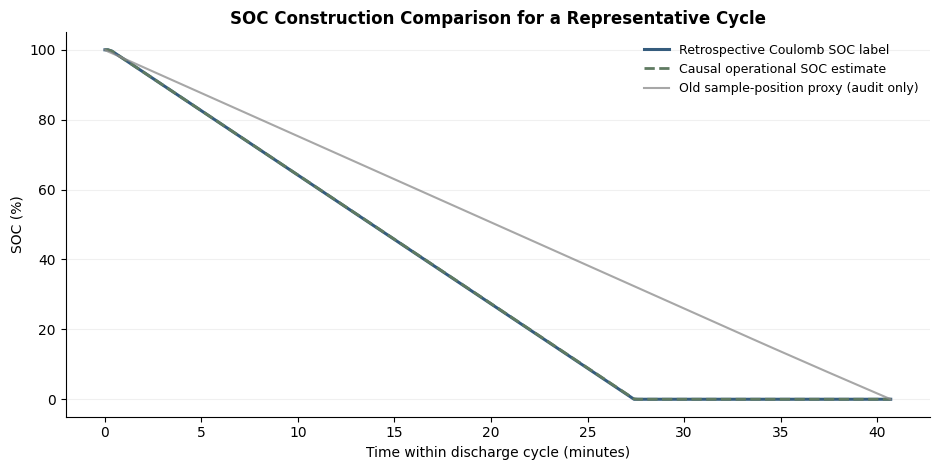

In [11]:
# 7. TARGET VALIDITY AND DATASET DIAGNOSTICS

# Compare the new target with the old sample position proxy target.
valid_proxy_comparison = model_df[
    ['soc_drop_120s', 'sample_position_proxy_drop_120s']
].dropna()

proxy_target_correlation = (
    valid_proxy_comparison.corr().iloc[0, 1]
    if len(valid_proxy_comparison) > 1
    else np.nan
)

# Within cycle variability: the old fixed sample target was constant by construction.
cycle_variability = (
    model_df.groupby(['battery_id', 'cycle_uid'], as_index=False)
    .agg(
        physical_target_std=('soc_drop_120s', 'std'),
        physical_target_range=(
            'soc_drop_120s',
            lambda s: float(s.max() - s.min()),
        ),
        proxy_target_std=('sample_position_proxy_drop_120s', 'std'),
        rows=('soc_drop_120s', 'size'),
    )
)

# Distribution by battery to avoid implying that rows are independent experiments.
battery_dataset_summary = (
    model_df.groupby('battery_id', as_index=False)
    .agg(
        modelling_rows=('soc_drop_120s', 'size'),
        discharge_cycles=('cycle_uid', 'nunique'),
        mean_soc_drop_120s=('soc_drop_120s', 'mean'),
        mean_horizon_seconds=('forecast_horizon_seconds', 'mean'),
        safe_rows=('future_risk_120s', lambda s: int((s == 'safe').sum())),
        warning_rows=('future_risk_120s', lambda s: int((s == 'warning').sum())),
        critical_rows=('future_risk_120s', lambda s: int((s == 'critical').sum())),
    )
)

# Current sign audit used by the downstream Gymnasium adapter.
current_sign_audit = pd.DataFrame(
    {
        'feature': ['current_measured_a', 'current_load_a'],
        'mean': [
            model_df['current_measured_a'].mean(),
            model_df['current_load_a'].mean(),
        ],
        'median': [
            model_df['current_measured_a'].median(),
            model_df['current_load_a'].median(),
        ],
        'proportion_negative': [
            (model_df['current_measured_a'] < 0).mean(),
            (model_df['current_load_a'] < 0).mean(),
        ],
    }
)

battery_dataset_summary.to_csv(
    AUDIT_OUTPUT_DIR / 'battery_level_dataset_summary.csv', index=False
)
cycle_variability.to_csv(
    AUDIT_OUTPUT_DIR / 'physical_target_within_cycle_variability.csv', index=False
)
current_sign_audit.to_csv(
    AUDIT_OUTPUT_DIR / 'current_sign_audit.csv', index=False
)

print('Correlation between physical SOC drop target and old proxy target:')
print(proxy_target_correlation)
print('\nPhysical target within cycle variability:')
display(cycle_variability[['physical_target_std', 'physical_target_range', 'proxy_target_std']].describe())
print('\nBattery level dataset summary:')
display(battery_dataset_summary)
print('\nCurrent sign audit:')
display(current_sign_audit)

# Representative cycle plot.
representative_cycle_uid = (
    cycle_variability
    .sort_values('physical_target_range', ascending=False)
    .iloc[len(cycle_variability) // 4]['cycle_uid']
)
representative_cycle = full_feature_df[
    full_feature_df['cycle_uid'] == representative_cycle_uid
].sort_values('time_s')

figure, axis = plt.subplots(figsize=(9.5, 4.8))
axis.plot(
    representative_cycle['time_s'] / 60.0,
    representative_cycle['true_coulomb_soc_percent'],
    label='Retrospective Coulomb SOC label',
    linewidth=2.2,
    color='#355C7D',
)
axis.plot(
    representative_cycle['time_s'] / 60.0,
    representative_cycle['operational_soc_percent'],
    label='Causal operational SOC estimate',
    linewidth=2.0,
    linestyle='--',
    color='#5F7A61',
)
axis.plot(
    representative_cycle['time_s'] / 60.0,
    representative_cycle['sample_position_soc_proxy'],
    label='Old sample-position proxy (audit only)',
    linewidth=1.5,
    alpha=0.75,
    color='#8A8A8A',
)
axis.set_xlabel('Time within discharge cycle (minutes)')
axis.set_ylabel('SOC (%)')
axis.set_title(
    'SOC Construction Comparison for a Representative Cycle',
    fontsize=12,
    fontweight='semibold',
)
axis.grid(axis='y', alpha=0.18, linewidth=0.8)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.legend(frameon=False, fontsize=9)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR / 'soc_construction_comparison.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

Observed EOL batteries: 19
Censored batteries: 15
RUL modelling rows: 1081


mae                 rmse             \
                                    mean       std       mean        std   
model                                                                      
HistGradientBoostingRegressor  21.014860  9.736601  26.786466  11.978698   
Ridge                          24.992376  3.067491  30.436232   3.404511   

                                     r2            
                                   mean       std  
model                                              
HistGradientBoostingRegressor  0.419384  0.230919  
Ridge                          0.051404  0.673030

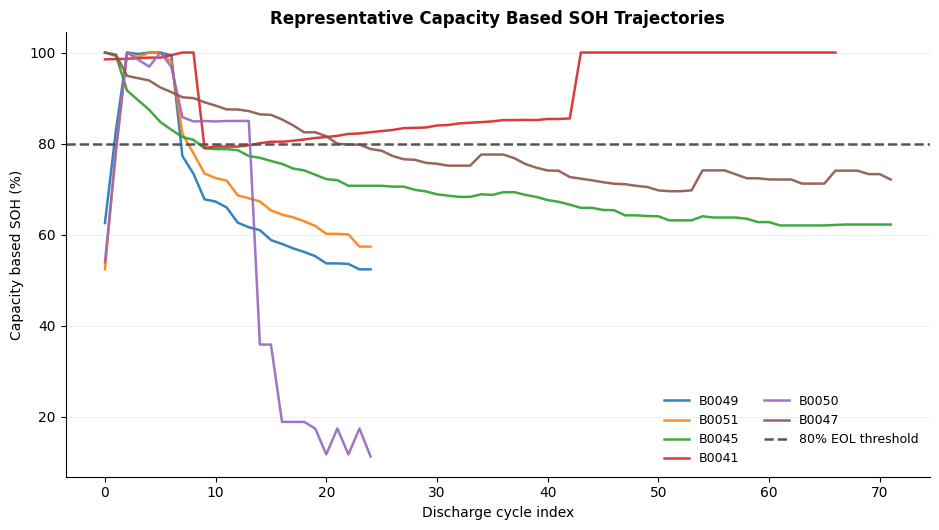

In [14]:
# 8. EXPLORATORY BATTERY LEVEL RUL MODELLING

rul_df = cycle_level[
    cycle_level['eol_observed']
    & cycle_level['rul_cycles'].notna()
    & (cycle_level['cycle_index'] <= cycle_level['eol_cycle_index'])
].copy()

rul_feature_cols = [
    'cycle_index',
    'measured_capacity_ah',
    'capacity_smoothed_ah',
    'soh_percent',
    'capacity_fade_percent',
    'mean_voltage_v',
    'mean_current_a',
    'mean_temperature_c',
]

rul_cv_rows = []

if rul_df['battery_id'].nunique() >= 5:
    rul_group_kfold = GroupKFold(
        n_splits=min(5, rul_df['battery_id'].nunique())
    )

    rul_models = {
        'Ridge': Pipeline(
            [
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', Ridge(alpha=10.0)),
            ]
        ),
        'HistGradientBoostingRegressor': Pipeline(
            [
                ('imputer', SimpleImputer(strategy='median')),
                (
                    'model',
                    HistGradientBoostingRegressor(
                        max_iter=250,
                        learning_rate=0.05,
                        max_leaf_nodes=15,
                        l2_regularization=1.0,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }

    for model_name, model in rul_models.items():
        for fold, (train_idx, val_idx) in enumerate(
            rul_group_kfold.split(
                rul_df[rul_feature_cols],
                rul_df['rul_cycles'],
                groups=rul_df['battery_id'],
            ),
            start=1,
        ):
            train_rows = rul_df.iloc[train_idx]
            val_rows = rul_df.iloc[val_idx]
            fitted = clone(model)
            fitted.fit(train_rows[rul_feature_cols], train_rows['rul_cycles'])
            predictions = fitted.predict(val_rows[rul_feature_cols])
            rul_cv_rows.append(
                {
                    'model': model_name,
                    'fold': fold,
                    'validation_batteries': ','.join(sorted(val_rows['battery_id'].unique())),
                    'mae': mean_absolute_error(val_rows['rul_cycles'], predictions),
                    'rmse': mean_squared_error(val_rows['rul_cycles'], predictions) ** 0.5,
                    'r2': r2_score(val_rows['rul_cycles'], predictions),
                }
            )

rul_cv_results_df = pd.DataFrame(rul_cv_rows)
rul_cv_results_df.to_csv(HEALTH_OUTPUT_DIR / 'rul_grouped_cv_results.csv', index=False)

print('Observed EOL batteries:', int(eol_summary['eol_observed'].sum()))
print('Censored batteries:', int((~eol_summary['eol_observed']).sum()))
print('RUL modelling rows:', len(rul_df))
if not rul_cv_results_df.empty:
    display(
        rul_cv_results_df.groupby('model')[['mae', 'rmse', 'r2']]
        .agg(['mean', 'std'])
    )
else:
    print('Insufficient observed EOL batteries for grouped RUL evaluation.')

# Compact SOH plot for representative observed EOL batteries.
figure, axis = plt.subplots(figsize=(9.5, 5.4))
selected_batteries = (
    eol_summary[eol_summary['eol_observed']]
    .sort_values('eol_cycle_index')
    .head(6)['battery_id']
    .tolist()
)
for battery_id in selected_batteries:
    temp = cycle_level[cycle_level['battery_id'] == battery_id]
    axis.plot(
        temp['cycle_index'],
        temp['soh_percent'],
        label=battery_id,
        linewidth=1.8,
        alpha=0.9,
    )
axis.axhline(
    EOL_SOH_THRESHOLD,
    linestyle='--',
    linewidth=1.8,
    color='#555555',
    label='80% EOL threshold',
)
axis.set_xlabel('Discharge cycle index')
axis.set_ylabel('Capacity based SOH (%)')
axis.set_title(
    'Representative Capacity Based SOH Trajectories',
    fontsize=12,
    fontweight='semibold',
)
axis.grid(axis='y', alpha=0.18, linewidth=0.8)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.legend(ncol=2, frameon=False, fontsize=9)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR / 'representative_soh_trajectories.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

In [15]:
# 9. FEATURE SETS, BATTERY HOLDOUT, AND GROUPED EVALUATION HELPERS

REGRESSION_TARGET = 'soc_drop_120s'
CLASSIFICATION_TARGET = 'future_risk_120s'

sensor_features = [
    'voltage_measured_v',
    'current_measured_a',
    'temperature_measured_c',
    'current_load_a',
    'voltage_load_v',
    'current_abs_rolling_mean_60s',
    'voltage_slope_v_per_min_60s',
    'temperature_rolling_mean_60s',
    'soc_slope_percent_per_min_60s',
    'power_proxy_w',
]

soc_features = ['operational_soc_percent']
health_features = [
    'prior_capacity_estimate_ah',
    'soh_percent_causal',
    'capacity_fade_percent_causal',
]
operational_features = ['time_s', 'cycle_index']

feature_sets = {
    'sensor_only': sensor_features,
    'sensor_soc': sensor_features + soc_features,
    'sensor_soc_health': sensor_features + soc_features + health_features,
    'operational_full': (
        sensor_features
        + soc_features
        + health_features
        + operational_features
    ),
}

all_model_features = sorted(set(sum(feature_sets.values(), [])))
missing_features = [
    feature
    for feature in all_model_features
    if feature not in model_df.columns
]
if missing_features:
    raise KeyError(f'Missing engineered model features: {missing_features}')

all_batteries = np.array(sorted(model_df['battery_id'].unique()))
if len(all_batteries) < 14:
    raise RuntimeError(
        'Too few batteries for grouped development and test evaluation.'
    )

split_rng = np.random.default_rng(RANDOM_STATE)
test_batteries = np.sort(
    split_rng.choice(
        all_batteries,
        size=TEST_BATTERY_COUNT,
        replace=False,
    )
)
test_battery_set = set(test_batteries)
trainval_batteries = np.array(
    [
        battery
        for battery in all_batteries
        if battery not in test_battery_set
    ]
)

trainval_df = model_df[
    model_df['battery_id'].isin(trainval_batteries)
].copy()
test_df = model_df[
    model_df['battery_id'].isin(test_batteries)
].copy()


def balanced_group_sample(
    frame,
    max_rows,
    group_col='battery_id',
    random_state=RANDOM_STATE,
):
    if len(frame) <= max_rows:
        return frame.copy().reset_index(drop=True)

    groups = list(frame[group_col].dropna().unique())
    per_group = max(max_rows // max(len(groups), 1), 1)
    sampled_parts = []

    for offset, group_value in enumerate(sorted(groups)):
        group_rows = frame[frame[group_col] == group_value]
        take = min(len(group_rows), per_group)
        sampled_parts.append(
            group_rows.sample(
                n=take,
                random_state=random_state + offset,
                replace=False,
            )
        )

    sampled = pd.concat(sampled_parts, ignore_index=False)

    if len(sampled) < max_rows:
        remaining = frame.drop(
            index=sampled.index,
            errors='ignore',
        )
        additional = min(
            max_rows - len(sampled),
            len(remaining),
        )
        if additional > 0:
            sampled = pd.concat(
                [
                    sampled,
                    remaining.sample(
                        n=additional,
                        random_state=random_state + 10_000,
                        replace=False,
                    ),
                ],
                ignore_index=False,
            )

    return (
        sampled
        .sample(frac=1.0, random_state=random_state)
        .reset_index(drop=True)
    )


cv_df = balanced_group_sample(trainval_df, MAX_CV_ROWS)
refit_df = balanced_group_sample(trainval_df, MAX_REFIT_ROWS)

group_kfold = GroupKFold(n_splits=N_GROUP_FOLDS)
risk_order = ['critical', 'warning', 'safe']
RISK_SEVERITY = {'safe': 0, 'warning': 1, 'critical': 2}


def critical_recall_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    actual_critical = y_true == 'critical'
    critical_count = int(actual_critical.sum())

    if critical_count == 0:
        return np.nan

    return float(
        (y_pred[actual_critical] == 'critical').mean()
    )


def critical_to_safe_rate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    actual_critical = y_true == 'critical'
    critical_count = int(actual_critical.sum())

    if critical_count == 0:
        return np.nan

    return float(
        (y_pred[actual_critical] == 'safe').mean()
    )


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'r2': r2_score(y_true, y_pred),
        'bias': float(np.mean(y_pred - y_true)),
    }


def classification_metrics(
    y_true,
    y_pred,
    battery_level=False,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    actual_labels = [
        label
        for label in risk_order
        if np.any(y_true == label)
    ]

    if battery_level:
        macro_labels = actual_labels
    else:
        macro_labels = risk_order

    macro_f1 = (
        f1_score(
            y_true,
            y_pred,
            labels=macro_labels,
            average='macro',
            zero_division=0,
        )
        if macro_labels
        else np.nan
    )

    critical_mask = y_true == 'critical'

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': macro_f1,
        'weighted_f1': f1_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        ),
        'critical_recall': critical_recall_score(
            y_true,
            y_pred,
        ),
        'critical_predicted_safe': int(
            (
                critical_mask
                & (y_pred == 'safe')
            ).sum()
        ),
        'critical_to_safe_rate': critical_to_safe_rate(
            y_true,
            y_pred,
        ),
        'critical_examples': int(critical_mask.sum()),
        'actual_class_count': int(len(actual_labels)),
        'actual_classes': ','.join(actual_labels),
    }


def bootstrap_mean_ci(
    values,
    iterations=BOOTSTRAP_ITERATIONS,
    random_state=RANDOM_STATE,
):
    values = np.asarray(
        pd.Series(values).dropna(),
        dtype=float,
    )

    if len(values) == 0:
        return {
            'mean': np.nan,
            'ci_low': np.nan,
            'ci_high': np.nan,
            'n_batteries': 0,
        }

    bootstrap_rng = np.random.default_rng(random_state)
    samples = bootstrap_rng.choice(
        values,
        size=(iterations, len(values)),
        replace=True,
    )
    means = samples.mean(axis=1)

    return {
        'mean': float(values.mean()),
        'ci_low': float(np.quantile(means, 0.025)),
        'ci_high': float(np.quantile(means, 0.975)),
        'n_batteries': int(len(values)),
    }


def paired_bootstrap_mean_ci(
    differences,
    iterations=BOOTSTRAP_ITERATIONS,
    random_state=RANDOM_STATE,
):
    """Bootstrap paired battery level differences."""
    differences = np.asarray(
        pd.Series(differences).dropna(),
        dtype=float,
    )

    if len(differences) == 0:
        return {
            'mean_difference': np.nan,
            'ci_low': np.nan,
            'ci_high': np.nan,
            'n_paired_batteries': 0,
        }

    bootstrap_rng = np.random.default_rng(random_state)
    samples = bootstrap_rng.choice(
        differences,
        size=(iterations, len(differences)),
        replace=True,
    )
    means = samples.mean(axis=1)

    return {
        'mean_difference': float(differences.mean()),
        'ci_low': float(np.quantile(means, 0.025)),
        'ci_high': float(np.quantile(means, 0.975)),
        'n_paired_batteries': int(len(differences)),
    }


print(
    'Development batteries:',
    len(trainval_batteries),
    trainval_batteries.tolist(),
)
print(
    'Held out test batteries:',
    len(test_batteries),
    test_batteries.tolist(),
)
print('Development rows:', len(trainval_df))
print('CV sample rows:', len(cv_df))
print('Refit sample rows:', len(refit_df))
print('Held out test rows:', len(test_df))


Development batteries: 25 ['B0005', 'B0006', 'B0018', 'B0025', 'B0026', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0044', 'B0045', 'B0047', 'B0048', 'B0050', 'B0051', 'B0053', 'B0055', 'B0056']
Held out test batteries: 9 ['B0007', 'B0027', 'B0033', 'B0041', 'B0043', 'B0046', 'B0049', 'B0052', 'B0054']
Development rows: 527161
CV sample rows: 80000
Refit sample rows: 200000
Held out test rows: 195815


In [16]:
# 10. GROUPED CV REGRESSION: PHYSICS, LINEAR, AND NONLINEAR MODELS

regression_model_specs = {
    'Ridge_alpha_0.1': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=0.1)),
        ]
    ),
    'Ridge_alpha_1': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=1.0)),
        ]
    ),
    'Ridge_alpha_10': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=10.0)),
        ]
    ),
    'HistGradientBoosting_leaf15': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                HistGradientBoostingRegressor(
                    max_iter=250,
                    learning_rate=0.05,
                    max_leaf_nodes=15,
                    l2_regularization=1.0,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    'HistGradientBoosting_leaf31': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                HistGradientBoostingRegressor(
                    max_iter=250,
                    learning_rate=0.05,
                    max_leaf_nodes=31,
                    l2_regularization=1.0,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

regression_cv_rows = []
regression_cv_predictions = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        cv_df,
        groups=cv_df['battery_id'],
    ),
    start=1,
):
    fold_train = cv_df.iloc[train_idx]
    fold_val = cv_df.iloc[val_idx]

    baseline_predictions = {
        'Mean baseline': np.full(
            len(fold_val),
            fold_train[REGRESSION_TARGET].mean(),
            dtype=float,
        ),
        'Constant current physics baseline': (
            fold_val['physics_soc_drop_baseline']
            .to_numpy(dtype=float)
        ),
    }

    for baseline_name, predictions in baseline_predictions.items():
        metrics = regression_metrics(
            fold_val[REGRESSION_TARGET],
            predictions,
        )
        regression_cv_rows.append(
            {
                'feature_set': 'baseline',
                'model': baseline_name,
                'fold': fold,
                'validation_batteries': ','.join(
                    sorted(fold_val['battery_id'].unique())
                ),
                **{
                    f'validation_{key}': value
                    for key, value in metrics.items()
                },
            }
        )

    for feature_set_name, feature_names in feature_sets.items():
        for model_name, model_spec in regression_model_specs.items():
            fitted = clone(model_spec)
            fitted.fit(
                fold_train[feature_names],
                fold_train[REGRESSION_TARGET],
            )
            predictions = np.clip(
                fitted.predict(fold_val[feature_names]),
                0.0,
                None,
            )
            metrics = regression_metrics(
                fold_val[REGRESSION_TARGET],
                predictions,
            )

            regression_cv_rows.append(
                {
                    'feature_set': feature_set_name,
                    'model': model_name,
                    'fold': fold,
                    'validation_batteries': ','.join(
                        sorted(fold_val['battery_id'].unique())
                    ),
                    **{
                        f'validation_{key}': value
                        for key, value in metrics.items()
                    },
                }
            )

            regression_cv_predictions.append(
                pd.DataFrame(
                    {
                        'battery_id': fold_val['battery_id'].values,
                        'cycle_uid': fold_val['cycle_uid'].values,
                        'fold': fold,
                        'feature_set': feature_set_name,
                        'model': model_name,
                        'actual_soc_drop_120s': (
                            fold_val[REGRESSION_TARGET].values
                        ),
                        'predicted_soc_drop_120s': predictions,
                    }
                )
            )

regression_cv_results_df = pd.DataFrame(regression_cv_rows)

regression_cv_summary_df = (
    regression_cv_results_df
    .groupby(
        ['feature_set', 'model'],
        as_index=False,
    )
    .agg(
        cv_rmse_mean=('validation_rmse', 'mean'),
        cv_rmse_std=('validation_rmse', 'std'),
        cv_mae_mean=('validation_mae', 'mean'),
        cv_mae_std=('validation_mae', 'std'),
        cv_r2_mean=('validation_r2', 'mean'),
        cv_bias_mean=('validation_bias', 'mean'),
    )
    .sort_values('cv_rmse_mean')
)

regression_cv_results_df.to_csv(
    EVALUATION_OUTPUT_DIR / 'regression_grouped_cv_folds.csv',
    index=False,
)
regression_cv_summary_df.to_csv(
    EVALUATION_OUTPUT_DIR / 'regression_grouped_cv_summary.csv',
    index=False,
)

if regression_cv_predictions:
    pd.concat(
        regression_cv_predictions,
        ignore_index=True,
    ).to_csv(
        EVALUATION_OUTPUT_DIR
        / 'regression_grouped_cv_predictions.csv',
        index=False,
    )

print('Grouped CV regression summary:')
display(regression_cv_summary_df)

Grouped CV regression summary:


,feature_set,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_bias_mean
13,sensor_soc,HistGradientBoosting_leaf31,1.978207,0.788253,0.536930,0.230171,0.701871,0.051244
2,operational_full,HistGradientBoosting_leaf15,2.126602,1.231404,0.634627,0.343740,0.640661,0.231060
17,sensor_soc_health,HistGradientBoosting_leaf15,2.212570,1.211212,0.693208,0.375733,0.613741,0.264822
12,sensor_soc,HistGradientBoosting_leaf15,2.283307,0.949040,0.756325,0.488797,0.576254,0.320362
8,sensor_only,HistGradientBoosting_leaf31,2.379552,1.005994,0.798433,0.586332,0.538526,0.307561
7,sensor_only,HistGradientBoosting_leaf15,2.446203,1.003840,0.871379,0.630251,0.508059,0.405408
18,sensor_soc_health,HistGradientBoosting_leaf31,2.464981,1.674488,0.642242,0.318817,0.498681,0.163746
3,operational_full,HistGradientBoosting_leaf31,2.467018,1.715135,0.631297,0.291305,0.494240,0.164581
5,operational_full,Ridge_alpha_1,2.539379,1.100805,0.965098,0.060133,0.513574,0.081490
4,operational_full,Ridge_alpha_0.1,2.539640,1.096118,0.968362,0.053888,0.513698,0.082456


In [17]:
# 11. GROUPED CV CLASSIFICATION: PERSISTENCE, PHYSICS, LINEAR, AND NONLINEAR MODELS

classification_model_specs = {
    'LogisticRegression_C0.1': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            (
                'model',
                LogisticRegression(
                    C=0.1,
                    max_iter=1_500,
                    solver='lbfgs',
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    'LogisticRegression_C1': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            (
                'model',
                LogisticRegression(
                    C=1.0,
                    max_iter=1_500,
                    solver='lbfgs',
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    'LogisticRegression_balanced_C1': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            (
                'model',
                LogisticRegression(
                    C=1.0,
                    max_iter=1_500,
                    solver='lbfgs',
                    class_weight='balanced',
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    'HistGradientBoosting_leaf15': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                HistGradientBoostingClassifier(
                    max_iter=250,
                    learning_rate=0.05,
                    max_leaf_nodes=15,
                    l2_regularization=1.0,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    'HistGradientBoosting_leaf31': Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                HistGradientBoostingClassifier(
                    max_iter=250,
                    learning_rate=0.05,
                    max_leaf_nodes=31,
                    l2_regularization=1.0,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

classification_cv_rows = []
classification_cv_predictions = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        cv_df,
        groups=cv_df['battery_id'],
    ),
    start=1,
):
    fold_train = cv_df.iloc[train_idx]
    fold_val = cv_df.iloc[val_idx]

    baseline_predictions = {
        'Current risk persistence baseline': (
            fold_val['current_risk_operational'].to_numpy()
        ),
        'Constant current physics risk baseline': (
            fold_val['physics_future_risk_baseline'].to_numpy()
        ),
    }

    for baseline_name, predictions in baseline_predictions.items():
        metrics = classification_metrics(
            fold_val[CLASSIFICATION_TARGET],
            predictions,
        )
        classification_cv_rows.append(
            {
                'feature_set': 'baseline',
                'model': baseline_name,
                'fold': fold,
                'validation_batteries': ','.join(
                    sorted(fold_val['battery_id'].unique())
                ),
                **{
                    f'validation_{key}': value
                    for key, value in metrics.items()
                },
                'validation_log_loss': np.nan,
                'low_confidence_fraction': np.nan,
            }
        )

    for feature_set_name, feature_names in feature_sets.items():
        for model_name, model_spec in classification_model_specs.items():
            fitted = clone(model_spec)
            fitted.fit(
                fold_train[feature_names],
                fold_train[CLASSIFICATION_TARGET],
            )

            predictions = fitted.predict(fold_val[feature_names])
            metrics = classification_metrics(
                fold_val[CLASSIFICATION_TARGET],
                predictions,
            )

            probabilities = fitted.predict_proba(
                fold_val[feature_names]
            )
            classes = list(fitted.classes_)
            fold_log_loss = log_loss(
                fold_val[CLASSIFICATION_TARGET],
                probabilities,
                labels=classes,
            )
            confidence = probabilities.max(axis=1)

            classification_cv_rows.append(
                {
                    'feature_set': feature_set_name,
                    'model': model_name,
                    'fold': fold,
                    'validation_batteries': ','.join(
                        sorted(fold_val['battery_id'].unique())
                    ),
                    **{
                        f'validation_{key}': value
                        for key, value in metrics.items()
                    },
                    'validation_log_loss': fold_log_loss,
                    'low_confidence_fraction': float(
                        (
                            confidence
                            < LOW_CONFIDENCE_THRESHOLD
                        ).mean()
                    ),
                }
            )

            classification_cv_predictions.append(
                pd.DataFrame(
                    {
                        'battery_id': fold_val['battery_id'].values,
                        'cycle_uid': fold_val['cycle_uid'].values,
                        'fold': fold,
                        'feature_set': feature_set_name,
                        'model': model_name,
                        'actual_future_risk_120s': (
                            fold_val[CLASSIFICATION_TARGET].values
                        ),
                        'predicted_future_risk_120s': predictions,
                        'prediction_confidence_uncalibrated': confidence,
                    }
                )
            )

classification_cv_results_df = pd.DataFrame(
    classification_cv_rows
)

classification_cv_summary_df = (
    classification_cv_results_df
    .groupby(
        ['feature_set', 'model'],
        as_index=False,
    )
    .agg(
        cv_macro_f1_mean=('validation_macro_f1', 'mean'),
        cv_macro_f1_std=('validation_macro_f1', 'std'),
        cv_critical_recall_mean=(
            'validation_critical_recall',
            'mean',
        ),
        cv_critical_recall_contributing_folds=(
            'validation_critical_recall',
            'count',
        ),
        cv_accuracy_mean=('validation_accuracy', 'mean'),
        cv_balanced_accuracy_mean=(
            'validation_balanced_accuracy',
            'mean',
        ),
        cv_log_loss_mean=('validation_log_loss', 'mean'),
        cv_critical_predicted_safe_total=(
            'validation_critical_predicted_safe',
            'sum',
        ),
    )
    .sort_values(
        [
            'cv_macro_f1_mean',
            'cv_critical_recall_mean',
        ],
        ascending=[False, False],
    )
)

classification_cv_results_df.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'classification_grouped_cv_folds.csv',
    index=False,
)
classification_cv_summary_df.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'classification_grouped_cv_summary.csv',
    index=False,
)

if classification_cv_predictions:
    pd.concat(
        classification_cv_predictions,
        ignore_index=True,
    ).to_csv(
        EVALUATION_OUTPUT_DIR
        / 'classification_grouped_cv_predictions.csv',
        index=False,
    )

print('Grouped CV classification summary:')
display(classification_cv_summary_df)

Grouped CV classification summary:


,feature_set,model,cv_macro_f1_mean,cv_macro_f1_std,cv_critical_recall_mean,cv_critical_recall_contributing_folds,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_log_loss_mean,cv_critical_predicted_safe_total
3,operational_full,HistGradientBoosting_leaf31,0.952873,0.020950,0.964199,4,0.962904,0.951766,0.112320,637
2,operational_full,HistGradientBoosting_leaf15,0.948091,0.019846,0.960273,4,0.959351,0.947271,0.117239,687
18,sensor_soc_health,HistGradientBoosting_leaf31,0.947281,0.018448,0.959042,4,0.958876,0.945694,0.140357,696
13,sensor_soc,HistGradientBoosting_leaf31,0.946204,0.013654,0.957270,4,0.958322,0.945500,0.114100,607
17,sensor_soc_health,HistGradientBoosting_leaf15,0.946082,0.018153,0.957632,4,0.957972,0.945304,0.130595,691
12,sensor_soc,HistGradientBoosting_leaf15,0.944299,0.016668,0.952378,4,0.956990,0.944869,0.112851,616
0,baseline,Constant current physics risk baseline,0.933937,0.030516,0.938453,4,0.945679,0.934024,NaN,810
20,sensor_soc_health,LogisticRegression_C1,0.904237,0.011870,0.937497,4,0.927054,0.903724,0.320243,558
19,sensor_soc_health,LogisticRegression_C0.1,0.902935,0.012500,0.932977,4,0.925433,0.902138,0.319682,729
21,sensor_soc_health,LogisticRegression_balanced_C1,0.900695,0.007804,0.909950,4,0.920206,0.916846,0.345907,503


In [18]:
# 12. SELECT MODELS, REFIT ON DEVELOPMENT BATTERIES, AND EVALUATE HELD OUT BATTERIES

regression_candidates = regression_cv_summary_df[
    regression_cv_summary_df['feature_set'] != 'baseline'
].copy()

classification_candidates = classification_cv_summary_df[
    classification_cv_summary_df['feature_set'] != 'baseline'
].copy()

best_reg_row = (
    regression_candidates
    .sort_values(
        ['cv_rmse_mean', 'cv_mae_mean']
    )
    .iloc[0]
)

practical_reg_row = (
    regression_candidates[
        regression_candidates['feature_set']
        == 'sensor_soc_health'
    ]
    .sort_values(
        ['cv_rmse_mean', 'cv_mae_mean']
    )
    .iloc[0]
)

best_cls_row = (
    classification_candidates
    .sort_values(
        [
            'cv_macro_f1_mean',
            'cv_critical_recall_mean',
        ],
        ascending=[False, False],
    )
    .iloc[0]
)

practical_cls_row = (
    classification_candidates[
        classification_candidates['feature_set']
        == 'sensor_soc_health'
    ]
    .sort_values(
        [
            'cv_macro_f1_mean',
            'cv_critical_recall_mean',
        ],
        ascending=[False, False],
    )
    .iloc[0]
)


def fit_selected_model(
    selection_row,
    model_specs,
    target,
):
    features = feature_sets[
        selection_row['feature_set']
    ]
    model = clone(
        model_specs[selection_row['model']]
    )
    model.fit(
        refit_df[features],
        refit_df[target],
    )
    return model, features


best_reg_model, best_reg_features = fit_selected_model(
    best_reg_row,
    regression_model_specs,
    REGRESSION_TARGET,
)
practical_reg_model, practical_reg_features = fit_selected_model(
    practical_reg_row,
    regression_model_specs,
    REGRESSION_TARGET,
)
best_cls_model, best_cls_features = fit_selected_model(
    best_cls_row,
    classification_model_specs,
    CLASSIFICATION_TARGET,
)
practical_cls_model, practical_cls_features = fit_selected_model(
    practical_cls_row,
    classification_model_specs,
    CLASSIFICATION_TARGET,
)


def evaluate_regression_model(
    model,
    features,
    label,
):
    predictions = np.clip(
        model.predict(test_df[features]),
        0.0,
        None,
    )

    pooled = regression_metrics(
        test_df[REGRESSION_TARGET],
        predictions,
    )

    prediction_df = test_df[
        [
            'battery_id',
            'cycle_uid',
            'cycle_index',
            'sample_index',
            'time_s',
            REGRESSION_TARGET,
            'physics_soc_drop_baseline',
        ]
    ].copy()

    prediction_df['predicted_soc_drop_120s'] = predictions
    prediction_df['model_label'] = label

    battery_rows = []
    for battery_id, battery_predictions in prediction_df.groupby(
        'battery_id'
    ):
        model_metrics = regression_metrics(
            battery_predictions[REGRESSION_TARGET],
            battery_predictions['predicted_soc_drop_120s'],
        )
        physics_metrics = regression_metrics(
            battery_predictions[REGRESSION_TARGET],
            battery_predictions['physics_soc_drop_baseline'],
        )

        battery_rows.append(
            {
                'battery_id': battery_id,
                'rows': len(battery_predictions),
                **{
                    f'model_{key}': value
                    for key, value in model_metrics.items()
                },
                **{
                    f'physics_{key}': value
                    for key, value in physics_metrics.items()
                },
                'model_minus_physics_mae': (
                    model_metrics['mae']
                    - physics_metrics['mae']
                ),
                'model_minus_physics_rmse': (
                    model_metrics['rmse']
                    - physics_metrics['rmse']
                ),
            }
        )

    battery_metrics = pd.DataFrame(battery_rows)
    return pooled, prediction_df, battery_metrics


def evaluate_classifier(
    model,
    features,
    label,
):
    predictions = model.predict(
        test_df[features]
    )
    probabilities = model.predict_proba(
        test_df[features]
    )
    confidence = probabilities.max(axis=1)

    pooled = classification_metrics(
        test_df[CLASSIFICATION_TARGET],
        predictions,
    )
    pooled['log_loss'] = log_loss(
        test_df[CLASSIFICATION_TARGET],
        probabilities,
        labels=list(model.classes_),
    )
    pooled['low_confidence_fraction'] = float(
        (
            confidence
            < LOW_CONFIDENCE_THRESHOLD
        ).mean()
    )

    prediction_df = test_df[
        [
            'battery_id',
            'cycle_uid',
            'cycle_index',
            'sample_index',
            'time_s',
            CLASSIFICATION_TARGET,
            'current_risk_operational',
            'physics_future_risk_baseline',
        ]
    ].copy()

    prediction_df['predicted_future_risk_120s'] = predictions
    prediction_df[
        'prediction_confidence_uncalibrated'
    ] = confidence
    prediction_df['model_label'] = label

    class_to_column = {
        str(class_name): index
        for index, class_name in enumerate(
            model.classes_
        )
    }

    for class_name in risk_order:
        if class_name in class_to_column:
            prediction_df[
                f'probability_{class_name}_uncalibrated'
            ] = probabilities[
                :,
                class_to_column[class_name],
            ]

    battery_rows = []

    for battery_id, battery_predictions in prediction_df.groupby(
        'battery_id'
    ):
        model_metrics = classification_metrics(
            battery_predictions[CLASSIFICATION_TARGET],
            battery_predictions[
                'predicted_future_risk_120s'
            ],
            battery_level=True,
        )

        persistence_metrics = classification_metrics(
            battery_predictions[CLASSIFICATION_TARGET],
            battery_predictions[
                'current_risk_operational'
            ],
            battery_level=True,
        )

        physics_metrics = classification_metrics(
            battery_predictions[CLASSIFICATION_TARGET],
            battery_predictions[
                'physics_future_risk_baseline'
            ],
            battery_level=True,
        )

        battery_rows.append(
            {
                'battery_id': battery_id,
                'rows': len(battery_predictions),
                **{
                    f'model_{key}': value
                    for key, value in model_metrics.items()
                },
                **{
                    f'persistence_{key}': value
                    for key, value in persistence_metrics.items()
                },
                **{
                    f'physics_{key}': value
                    for key, value in physics_metrics.items()
                },
                'model_minus_persistence_macro_f1': (
                    model_metrics['macro_f1']
                    - persistence_metrics['macro_f1']
                ),
                'model_minus_physics_macro_f1': (
                    model_metrics['macro_f1']
                    - physics_metrics['macro_f1']
                ),
                'model_minus_persistence_critical_recall': (
                    model_metrics['critical_recall']
                    - persistence_metrics['critical_recall']
                    if (
                        np.isfinite(model_metrics['critical_recall'])
                        and np.isfinite(
                            persistence_metrics[
                                'critical_recall'
                            ]
                        )
                    )
                    else np.nan
                ),
                'model_minus_physics_critical_recall': (
                    model_metrics['critical_recall']
                    - physics_metrics['critical_recall']
                    if (
                        np.isfinite(model_metrics['critical_recall'])
                        and np.isfinite(
                            physics_metrics[
                                'critical_recall'
                            ]
                        )
                    )
                    else np.nan
                ),
                'model_minus_persistence_critical_to_safe_rate': (
                    model_metrics['critical_to_safe_rate']
                    - persistence_metrics[
                        'critical_to_safe_rate'
                    ]
                    if (
                        np.isfinite(
                            model_metrics[
                                'critical_to_safe_rate'
                            ]
                        )
                        and np.isfinite(
                            persistence_metrics[
                                'critical_to_safe_rate'
                            ]
                        )
                    )
                    else np.nan
                ),
                'model_minus_physics_critical_to_safe_rate': (
                    model_metrics['critical_to_safe_rate']
                    - physics_metrics[
                        'critical_to_safe_rate'
                    ]
                    if (
                        np.isfinite(
                            model_metrics[
                                'critical_to_safe_rate'
                            ]
                        )
                        and np.isfinite(
                            physics_metrics[
                                'critical_to_safe_rate'
                            ]
                        )
                    )
                    else np.nan
                ),
            }
        )

    battery_metrics = pd.DataFrame(
        battery_rows
    )
    return pooled, prediction_df, battery_metrics


best_reg_pooled, best_reg_predictions, best_reg_battery = (
    evaluate_regression_model(
        best_reg_model,
        best_reg_features,
        'best_overall',
    )
)

(
    practical_reg_pooled,
    practical_reg_predictions,
    practical_reg_battery,
) = evaluate_regression_model(
    practical_reg_model,
    practical_reg_features,
    'practical_bms_style',
)

best_cls_pooled, best_cls_predictions, best_cls_battery = (
    evaluate_classifier(
        best_cls_model,
        best_cls_features,
        'best_overall',
    )
)

(
    practical_cls_pooled,
    practical_cls_predictions,
    practical_cls_battery,
) = evaluate_classifier(
    practical_cls_model,
    practical_cls_features,
    'practical_bms_style',
)

mean_test_predictions = np.full(
    len(test_df),
    refit_df[REGRESSION_TARGET].mean(),
)

physics_test_predictions = (
    test_df['physics_soc_drop_baseline']
    .to_numpy(dtype=float)
)

regression_test_baselines = pd.DataFrame(
    [
        {
            'model': 'Mean baseline',
            **regression_metrics(
                test_df[REGRESSION_TARGET],
                mean_test_predictions,
            ),
        },
        {
            'model': 'Constant current physics baseline',
            **regression_metrics(
                test_df[REGRESSION_TARGET],
                physics_test_predictions,
            ),
        },
    ]
)

classification_test_baselines = pd.DataFrame(
    [
        {
            'model': 'Current risk persistence baseline',
            **classification_metrics(
                test_df[CLASSIFICATION_TARGET],
                test_df[
                    'current_risk_operational'
                ],
            ),
        },
        {
            'model': 'Constant current physics risk baseline',
            **classification_metrics(
                test_df[CLASSIFICATION_TARGET],
                test_df[
                    'physics_future_risk_baseline'
                ],
            ),
        },
    ]
)

final_test_summary = pd.DataFrame(
    [
        {
            'task': 'soc_drop_regression',
            'bundle': 'best_overall',
            'feature_set': best_reg_row['feature_set'],
            'model': best_reg_row['model'],
            **best_reg_pooled,
        },
        {
            'task': 'soc_drop_regression',
            'bundle': 'practical_bms_style',
            'feature_set': practical_reg_row[
                'feature_set'
            ],
            'model': practical_reg_row['model'],
            **practical_reg_pooled,
        },
        {
            'task': 'future_risk_classification',
            'bundle': 'best_overall',
            'feature_set': best_cls_row['feature_set'],
            'model': best_cls_row['model'],
            **best_cls_pooled,
        },
        {
            'task': 'future_risk_classification',
            'bundle': 'practical_bms_style',
            'feature_set': practical_cls_row[
                'feature_set'
            ],
            'model': practical_cls_row['model'],
            **practical_cls_pooled,
        },
    ]
)

bootstrap_rows = []

for bundle, task, battery_metrics, metric_columns in [
    (
        'best_overall',
        'soc_drop_regression',
        best_reg_battery,
        {
            'mae': 'model_mae',
            'rmse': 'model_rmse',
            'r2': 'model_r2',
        },
    ),
    (
        'practical_bms_style',
        'soc_drop_regression',
        practical_reg_battery,
        {
            'mae': 'model_mae',
            'rmse': 'model_rmse',
            'r2': 'model_r2',
        },
    ),
    (
        'best_overall',
        'future_risk_classification',
        best_cls_battery,
        {
            'accuracy': 'model_accuracy',
            'macro_f1_observed_classes': 'model_macro_f1',
            'critical_recall': 'model_critical_recall',
        },
    ),
    (
        'practical_bms_style',
        'future_risk_classification',
        practical_cls_battery,
        {
            'accuracy': 'model_accuracy',
            'macro_f1_observed_classes': 'model_macro_f1',
            'critical_recall': 'model_critical_recall',
        },
    ),
]:
    for metric_name, column_name in metric_columns.items():
        interval = bootstrap_mean_ci(
            battery_metrics[column_name]
        )
        bootstrap_rows.append(
            {
                'bundle': bundle,
                'task': task,
                'metric': metric_name,
                **interval,
            }
        )

battery_bootstrap_ci_df = pd.DataFrame(
    bootstrap_rows
)

paired_rows = []

for bundle, regression_battery in [
    ('best_overall', best_reg_battery),
    ('practical_bms_style', practical_reg_battery),
]:
    for metric_name, difference_column in [
        (
            'rmse_model_minus_physics',
            'model_minus_physics_rmse',
        ),
        (
            'mae_model_minus_physics',
            'model_minus_physics_mae',
        ),
    ]:
        paired_rows.append(
            {
                'bundle': bundle,
                'task': 'soc_drop_regression',
                'comparison': 'model_minus_physics',
                'metric': metric_name,
                **paired_bootstrap_mean_ci(
                    regression_battery[
                        difference_column
                    ]
                ),
            }
        )

for bundle, classification_battery in [
    ('best_overall', best_cls_battery),
    (
        'practical_bms_style',
        practical_cls_battery,
    ),
]:
    for comparison_name, prefix in [
        ('model_minus_persistence', 'persistence'),
        ('model_minus_physics', 'physics'),
    ]:
        for metric_name in [
            'macro_f1',
            'critical_recall',
            'critical_to_safe_rate',
        ]:
            difference_column = (
                f'model_minus_{prefix}_{metric_name}'
            )
            paired_rows.append(
                {
                    'bundle': bundle,
                    'task': (
                        'future_risk_classification'
                    ),
                    'comparison': comparison_name,
                    'metric': metric_name,
                    **paired_bootstrap_mean_ci(
                        classification_battery[
                            difference_column
                        ]
                    ),
                }
            )

paired_battery_difference_ci_df = pd.DataFrame(
    paired_rows
)

final_test_summary.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'final_test_summary.csv',
    index=False,
)
regression_test_baselines.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'regression_test_baselines.csv',
    index=False,
)
classification_test_baselines.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'classification_test_baselines.csv',
    index=False,
)
battery_bootstrap_ci_df.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'battery_level_bootstrap_confidence_intervals.csv',
    index=False,
)
paired_battery_difference_ci_df.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'paired_battery_model_minus_baseline_intervals.csv',
    index=False,
)

best_reg_predictions.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'best_regression_test_predictions.csv',
    index=False,
)
practical_reg_predictions.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'practical_regression_test_predictions.csv',
    index=False,
)
best_cls_predictions.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'best_classification_test_predictions.csv',
    index=False,
)
practical_cls_predictions.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'practical_classification_test_predictions.csv',
    index=False,
)

best_reg_battery.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'best_regression_metrics_by_battery.csv',
    index=False,
)
practical_reg_battery.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'practical_regression_metrics_by_battery.csv',
    index=False,
)
best_cls_battery.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'best_classification_metrics_by_battery.csv',
    index=False,
)
practical_cls_battery.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'practical_classification_metrics_by_battery.csv',
    index=False,
)

print(
    'Selected best overall regression:',
    best_reg_row[
        ['feature_set', 'model']
    ].to_dict(),
)
print(
    'Selected practical regression:',
    practical_reg_row[
        ['feature_set', 'model']
    ].to_dict(),
)
print(
    'Selected best overall classifier:',
    best_cls_row[
        ['feature_set', 'model']
    ].to_dict(),
)
print(
    'Selected practical classifier:',
    practical_cls_row[
        ['feature_set', 'model']
    ].to_dict(),
)
print('\nHeld out test summary:')
display(final_test_summary)
print('\nHeld out regression baselines:')
display(regression_test_baselines)
print('\nHeld out classification baselines:')
display(classification_test_baselines)
print('\nBattery level bootstrap intervals:')
display(battery_bootstrap_ci_df)
print('\nPaired model minus baseline intervals:')
display(paired_battery_difference_ci_df)

Selected best overall regression: {'feature_set': 'sensor_soc', 'model': 'HistGradientBoosting_leaf31'}
Selected practical regression: {'feature_set': 'sensor_soc_health', 'model': 'HistGradientBoosting_leaf15'}
Selected best overall classifier: {'feature_set': 'operational_full', 'model': 'HistGradientBoosting_leaf31'}
Selected practical classifier: {'feature_set': 'sensor_soc_health', 'model': 'HistGradientBoosting_leaf31'}

Held out test summary:


,task,bundle,feature_set,model,mae,rmse,r2,bias,accuracy,balanced_accuracy,macro_f1,weighted_f1,critical_recall,critical_predicted_safe,critical_to_safe_rate,critical_examples,actual_class_count,actual_classes,log_loss,low_confidence_fraction
0,soc_drop_regression,best_overall,sensor_soc,HistGradientBoosting_leaf31,0.365135,2.221409,0.763456,0.011146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,soc_drop_regression,practical_bms_style,sensor_soc_health,HistGradientBoosting_leaf15,0.307445,1.757921,0.851866,-0.037516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,future_risk_classification,best_overall,operational_full,HistGradientBoosting_leaf31,NaN,NaN,NaN,NaN,0.972357,0.958064,0.961756,0.972207,0.989603,127.0,0.001485,85507.0,3.0,"critical,warning,safe",0.090809,0.008917
3,future_risk_classification,practical_bms_style,sensor_soc_health,HistGradientBoosting_leaf31,NaN,NaN,NaN,NaN,0.969681,0.955637,0.958062,0.969569,0.989919,169.0,0.001976,85507.0,3.0,"critical,warning,safe",0.100791,0.009606



Held out regression baselines:


,model,mae,rmse,r2,bias
0,Mean baseline,2.345429,4.574162,-0.002947,0.247949
1,Constant current physics baseline,1.984334,11.715212,-5.578929,1.547123



Held out classification baselines:


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,critical_recall,critical_predicted_safe,critical_to_safe_rate,critical_examples,actual_class_count,actual_classes
0,Current risk persistence baseline,0.898665,0.856181,0.856262,0.898286,0.891354,1356,0.015858,85507,3,"critical,warning,safe"
1,Constant current physics risk baseline,0.958251,0.945458,0.946933,0.958186,0.966938,1118,0.013075,85507,3,"critical,warning,safe"



Battery level bootstrap intervals:


,bundle,task,metric,mean,ci_low,ci_high,n_batteries
0,best_overall,soc_drop_regression,mae,0.490556,0.316961,0.667721,9
1,best_overall,soc_drop_regression,rmse,1.973509,1.088490,2.988110,9
2,best_overall,soc_drop_regression,r2,0.373839,-0.371828,0.820188,9
3,practical_bms_style,soc_drop_regression,mae,0.396132,0.270330,0.524590,9
4,practical_bms_style,soc_drop_regression,rmse,1.419603,0.656396,2.408272,9
5,practical_bms_style,soc_drop_regression,r2,0.859952,0.815465,0.897087,9
6,best_overall,future_risk_classification,accuracy,0.966350,0.940896,0.983965,9
7,best_overall,future_risk_classification,macro_f1_observed_classes,0.944924,0.901612,0.974811,9
8,best_overall,future_risk_classification,critical_recall,0.986868,0.980882,0.992798,9
9,practical_bms_style,future_risk_classification,accuracy,0.961329,0.931908,0.982061,9



Paired model minus baseline intervals:


,bundle,task,comparison,metric,mean_difference,ci_low,ci_high,n_paired_batteries
0,best_overall,soc_drop_regression,model_minus_physics,rmse_model_minus_physics,-5.994533,-12.785048,-0.866078,9
1,best_overall,soc_drop_regression,model_minus_physics,mae_model_minus_physics,-2.025585,-4.240809,-0.388198,9
2,practical_bms_style,soc_drop_regression,model_minus_physics,rmse_model_minus_physics,-6.548438,-13.277860,-1.319487,9
3,practical_bms_style,soc_drop_regression,model_minus_physics,mae_model_minus_physics,-2.120009,-4.323614,-0.505667,9
4,best_overall,future_risk_classification,model_minus_persistence,macro_f1,0.128155,0.053368,0.187524,9
5,best_overall,future_risk_classification,model_minus_persistence,critical_recall,0.104762,0.065852,0.142680,9
6,best_overall,future_risk_classification,model_minus_persistence,critical_to_safe_rate,-0.012652,-0.026148,-0.002087,9
7,best_overall,future_risk_classification,model_minus_physics,macro_f1,0.045339,-0.036337,0.119714,9
8,best_overall,future_risk_classification,model_minus_physics,critical_recall,0.028300,0.007858,0.051052,9
9,best_overall,future_risk_classification,model_minus_physics,critical_to_safe_rate,-0.008513,-0.019365,-0.000954,9


In [19]:
# 13. REPEATED BATTERY SPLIT SENSITIVITY AND FAILURE CASE ANALYSIS

sensitivity_rows = []
sensitivity_battery_rows = []

sensitivity_seeds = [
    RANDOM_STATE + 37 * index
    for index in range(N_SPLIT_SENSITIVITY_RUNS)
]

for split_number, split_seed in enumerate(
    sensitivity_seeds,
    start=1,
):
    split_rng = np.random.default_rng(split_seed)
    sensitivity_test_batteries = np.sort(
        split_rng.choice(
            all_batteries,
            size=TEST_BATTERY_COUNT,
            replace=False,
        )
    )
    sensitivity_test_set = set(
        sensitivity_test_batteries
    )

    sensitivity_train_df = model_df[
        ~model_df['battery_id'].isin(
            sensitivity_test_set
        )
    ]
    sensitivity_test_df = model_df[
        model_df['battery_id'].isin(
            sensitivity_test_set
        )
    ]

    sensitivity_train_sample = balanced_group_sample(
        sensitivity_train_df,
        MAX_SENSITIVITY_TRAIN_ROWS,
        random_state=split_seed,
    )

    sensitivity_reg_model = clone(
        regression_model_specs[
            best_reg_row['model']
        ]
    )
    sensitivity_reg_features = feature_sets[
        best_reg_row['feature_set']
    ]
    sensitivity_reg_model.fit(
        sensitivity_train_sample[
            sensitivity_reg_features
        ],
        sensitivity_train_sample[
            REGRESSION_TARGET
        ],
    )

    sensitivity_reg_predictions = np.clip(
        sensitivity_reg_model.predict(
            sensitivity_test_df[
                sensitivity_reg_features
            ]
        ),
        0.0,
        None,
    )
    sensitivity_physics_predictions = (
        sensitivity_test_df[
            'physics_soc_drop_baseline'
        ].to_numpy(dtype=float)
    )

    model_regression_metrics = regression_metrics(
        sensitivity_test_df[
            REGRESSION_TARGET
        ],
        sensitivity_reg_predictions,
    )
    physics_regression_metrics = regression_metrics(
        sensitivity_test_df[
            REGRESSION_TARGET
        ],
        sensitivity_physics_predictions,
    )

    sensitivity_cls_model = clone(
        classification_model_specs[
            best_cls_row['model']
        ]
    )
    sensitivity_cls_features = feature_sets[
        best_cls_row['feature_set']
    ]
    sensitivity_cls_model.fit(
        sensitivity_train_sample[
            sensitivity_cls_features
        ],
        sensitivity_train_sample[
            CLASSIFICATION_TARGET
        ],
    )

    sensitivity_cls_predictions = (
        sensitivity_cls_model.predict(
            sensitivity_test_df[
                sensitivity_cls_features
            ]
        )
    )
    sensitivity_persistence_predictions = (
        sensitivity_test_df[
            'current_risk_operational'
        ].to_numpy()
    )
    sensitivity_physics_risk_predictions = (
        sensitivity_test_df[
            'physics_future_risk_baseline'
        ].to_numpy()
    )

    model_classification_metrics = (
        classification_metrics(
            sensitivity_test_df[
                CLASSIFICATION_TARGET
            ],
            sensitivity_cls_predictions,
        )
    )
    persistence_classification_metrics = (
        classification_metrics(
            sensitivity_test_df[
                CLASSIFICATION_TARGET
            ],
            sensitivity_persistence_predictions,
        )
    )
    physics_classification_metrics = (
        classification_metrics(
            sensitivity_test_df[
                CLASSIFICATION_TARGET
            ],
            sensitivity_physics_risk_predictions,
        )
    )

    sensitivity_rows.append(
        {
            'split_number': split_number,
            'seed': split_seed,
            'test_batteries': ','.join(
                sensitivity_test_batteries
            ),
            'test_rows': len(
                sensitivity_test_df
            ),
            'regression_model_rmse': (
                model_regression_metrics['rmse']
            ),
            'regression_physics_rmse': (
                physics_regression_metrics['rmse']
            ),
            'regression_model_minus_physics_rmse': (
                model_regression_metrics['rmse']
                - physics_regression_metrics['rmse']
            ),
            'regression_model_mae': (
                model_regression_metrics['mae']
            ),
            'regression_physics_mae': (
                physics_regression_metrics['mae']
            ),
            'regression_model_minus_physics_mae': (
                model_regression_metrics['mae']
                - physics_regression_metrics['mae']
            ),
            'classification_model_macro_f1': (
                model_classification_metrics[
                    'macro_f1'
                ]
            ),
            'classification_persistence_macro_f1': (
                persistence_classification_metrics[
                    'macro_f1'
                ]
            ),
            'classification_physics_macro_f1': (
                physics_classification_metrics[
                    'macro_f1'
                ]
            ),
            'classification_model_minus_persistence_macro_f1': (
                model_classification_metrics[
                    'macro_f1'
                ]
                - persistence_classification_metrics[
                    'macro_f1'
                ]
            ),
            'classification_model_minus_physics_macro_f1': (
                model_classification_metrics[
                    'macro_f1'
                ]
                - physics_classification_metrics[
                    'macro_f1'
                ]
            ),
            'classification_model_critical_recall': (
                model_classification_metrics[
                    'critical_recall'
                ]
            ),
            'classification_persistence_critical_recall': (
                persistence_classification_metrics[
                    'critical_recall'
                ]
            ),
            'classification_physics_critical_recall': (
                physics_classification_metrics[
                    'critical_recall'
                ]
            ),
        }
    )

    split_prediction_frame = sensitivity_test_df[
        [
            'battery_id',
            REGRESSION_TARGET,
            CLASSIFICATION_TARGET,
            'physics_soc_drop_baseline',
            'current_risk_operational',
            'physics_future_risk_baseline',
        ]
    ].copy()
    split_prediction_frame[
        'model_soc_drop_prediction'
    ] = sensitivity_reg_predictions
    split_prediction_frame[
        'model_risk_prediction'
    ] = sensitivity_cls_predictions

    for battery_id, battery_rows in (
        split_prediction_frame
        .groupby('battery_id')
    ):
        battery_model_reg = regression_metrics(
            battery_rows[REGRESSION_TARGET],
            battery_rows[
                'model_soc_drop_prediction'
            ],
        )
        battery_physics_reg = regression_metrics(
            battery_rows[REGRESSION_TARGET],
            battery_rows[
                'physics_soc_drop_baseline'
            ],
        )
        battery_model_cls = classification_metrics(
            battery_rows[
                CLASSIFICATION_TARGET
            ],
            battery_rows[
                'model_risk_prediction'
            ],
            battery_level=True,
        )
        battery_persistence_cls = (
            classification_metrics(
                battery_rows[
                    CLASSIFICATION_TARGET
                ],
                battery_rows[
                    'current_risk_operational'
                ],
                battery_level=True,
            )
        )
        battery_physics_cls = classification_metrics(
            battery_rows[
                CLASSIFICATION_TARGET
            ],
            battery_rows[
                'physics_future_risk_baseline'
            ],
            battery_level=True,
        )

        sensitivity_battery_rows.append(
            {
                'split_number': split_number,
                'seed': split_seed,
                'battery_id': battery_id,
                'rows': len(battery_rows),
                'model_rmse': (
                    battery_model_reg['rmse']
                ),
                'physics_rmse': (
                    battery_physics_reg['rmse']
                ),
                'model_minus_physics_rmse': (
                    battery_model_reg['rmse']
                    - battery_physics_reg['rmse']
                ),
                'model_mae': (
                    battery_model_reg['mae']
                ),
                'physics_mae': (
                    battery_physics_reg['mae']
                ),
                'model_minus_physics_mae': (
                    battery_model_reg['mae']
                    - battery_physics_reg['mae']
                ),
                'model_macro_f1': (
                    battery_model_cls[
                        'macro_f1'
                    ]
                ),
                'persistence_macro_f1': (
                    battery_persistence_cls[
                        'macro_f1'
                    ]
                ),
                'physics_macro_f1': (
                    battery_physics_cls[
                        'macro_f1'
                    ]
                ),
                'model_minus_persistence_macro_f1': (
                    battery_model_cls[
                        'macro_f1'
                    ]
                    - battery_persistence_cls[
                        'macro_f1'
                    ]
                ),
                'model_minus_physics_macro_f1': (
                    battery_model_cls[
                        'macro_f1'
                    ]
                    - battery_physics_cls[
                        'macro_f1'
                    ]
                ),
                'critical_recall': (
                    battery_model_cls[
                        'critical_recall'
                    ]
                ),
                'critical_examples': (
                    battery_model_cls[
                        'critical_examples'
                    ]
                ),
            }
        )

split_sensitivity_df = pd.DataFrame(
    sensitivity_rows
)
split_sensitivity_battery_df = pd.DataFrame(
    sensitivity_battery_rows
)

split_sensitivity_df.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'repeated_battery_split_sensitivity.csv',
    index=False,
)
split_sensitivity_battery_df.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'repeated_split_metrics_by_battery.csv',
    index=False,
)

sensitivity_summary_rows = []
for metric_name in [
    'regression_model_minus_physics_rmse',
    'regression_model_minus_physics_mae',
    'classification_model_minus_persistence_macro_f1',
    'classification_model_minus_physics_macro_f1',
]:
    interval = bootstrap_mean_ci(
        split_sensitivity_df[metric_name],
        random_state=RANDOM_STATE + 500,
    )
    sensitivity_summary_rows.append(
        {
            'metric': metric_name,
            **interval,
            'proportion_model_better': float(
                (
                    split_sensitivity_df[metric_name]
                    < 0
                ).mean()
                if metric_name.startswith(
                    'regression'
                )
                else (
                    split_sensitivity_df[
                        metric_name
                    ]
                    > 0
                ).mean()
            ),
        }
    )

split_sensitivity_summary_df = pd.DataFrame(
    sensitivity_summary_rows
)
split_sensitivity_summary_df.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'repeated_battery_split_sensitivity_summary.csv',
    index=False,
)

# Failure case tables for the untouched final test split.
regression_failure_cases = (
    best_reg_predictions
    .assign(
        absolute_error=lambda frame: np.abs(
            frame[
                'predicted_soc_drop_120s'
            ]
            - frame[REGRESSION_TARGET]
        )
    )
    .sort_values(
        'absolute_error',
        ascending=False,
    )
    .head(250)
)

classification_failure_cases = (
    best_cls_predictions[
        best_cls_predictions[
            'predicted_future_risk_120s'
        ]
        != best_cls_predictions[
            CLASSIFICATION_TARGET
        ]
    ]
    .copy()
)

classification_failure_cases[
    'actual_severity'
] = classification_failure_cases[
    CLASSIFICATION_TARGET
].map(RISK_SEVERITY)

classification_failure_cases[
    'predicted_severity'
] = classification_failure_cases[
    'predicted_future_risk_120s'
].map(RISK_SEVERITY)

classification_failure_cases[
    'severity_error'
] = (
    classification_failure_cases[
        'predicted_severity'
    ]
    - classification_failure_cases[
        'actual_severity'
    ]
)

classification_failure_cases = (
    classification_failure_cases
    .sort_values(
        [
            'severity_error',
            'prediction_confidence_uncalibrated',
        ],
        ascending=[True, False],
    )
    .head(500)
)

regression_failure_cases.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'largest_regression_errors.csv',
    index=False,
)
classification_failure_cases.to_csv(
    EVALUATION_OUTPUT_DIR
    / 'classification_failure_cases.csv',
    index=False,
)

print('Repeated battery split sensitivity:')
display(split_sensitivity_df)
print('\nSensitivity summary:')
display(split_sensitivity_summary_df)
print('\nWorst held out regression batteries:')
display(
    best_reg_battery
    .sort_values(
        'model_rmse',
        ascending=False,
    )
)
print('\nHeld out classification batteries:')
display(
    best_cls_battery
    .sort_values(
        'model_macro_f1',
        ascending=True,
    )
)

Repeated battery split sensitivity:


,split_number,seed,test_batteries,test_rows,regression_model_rmse,regression_physics_rmse,regression_model_minus_physics_rmse,regression_model_mae,regression_physics_mae,regression_model_minus_physics_mae,classification_model_macro_f1,classification_persistence_macro_f1,classification_physics_macro_f1,classification_model_minus_persistence_macro_f1,classification_model_minus_physics_macro_f1,classification_model_critical_recall,classification_persistence_critical_recall,classification_physics_critical_recall
0,1,42,"B0007,B0027,B0033,B0041,B0043,B0046,B0049,B005...",195815,2.252408,11.715212,-9.462804,0.387635,1.984334,-1.596699,0.963169,0.856262,0.946933,0.106907,0.016236,0.987674,0.891354,0.966938
1,2,79,"B0006,B0007,B0031,B0043,B0047,B0050,B0051,B005...",170403,2.235671,7.732056,-5.496385,0.315545,1.118471,-0.802926,0.973393,0.849260,0.939801,0.124133,0.033592,0.983777,0.810465,0.931414
2,3,116,"B0025,B0027,B0029,B0036,B0048,B0052,B0053,B005...",158204,1.026210,1.722175,-0.695964,0.297911,0.580287,-0.282376,0.954493,0.875983,0.968268,0.078510,-0.013775,0.987475,0.882474,0.981824
3,4,153,"B0018,B0036,B0038,B0040,B0041,B0047,B0048,B005...",202519,1.646190,8.354164,-6.707974,0.267324,0.942451,-0.675127,0.969638,0.870521,0.945789,0.099117,0.023849,0.984574,0.851151,0.960780
4,5,190,"B0006,B0007,B0025,B0027,B0028,B0032,B0036,B004...",227433,1.512281,6.434307,-4.922027,0.267968,0.736980,-0.469012,0.963950,0.880298,0.970664,0.083651,-0.006714,0.994896,0.863941,0.975825
5,6,227,"B0026,B0028,B0031,B0033,B0034,B0036,B0042,B004...",239642,1.972158,15.953747,-13.981589,0.442409,2.344946,-1.902538,0.960131,0.866451,0.958795,0.093679,0.001336,0.991963,0.896923,0.973719
6,7,264,"B0006,B0018,B0031,B0034,B0038,B0046,B0051,B005...",211459,0.862939,1.957479,-1.094539,0.322885,0.694349,-0.371464,0.971784,0.860194,0.955019,0.111590,0.016765,0.987619,0.884382,0.976176
7,8,301,"B0025,B0026,B0027,B0031,B0032,B0034,B0045,B005...",157320,2.714885,1.888253,0.826631,1.135164,0.643128,0.492036,0.934306,0.851230,0.962620,0.083075,-0.028314,0.992586,0.923241,0.984311



Sensitivity summary:


,metric,mean,ci_low,ci_high,n_batteries,proportion_model_better
0,regression_model_minus_physics_rmse,-5.191831,-8.687082,-2.075283,8,0.875
1,regression_model_minus_physics_mae,-0.701013,-1.203617,-0.221392,8,0.875
2,classification_model_minus_persistence_macro_f1,0.097583,0.087815,0.108347,8,1.000
3,classification_model_minus_physics_macro_f1,0.005372,-0.008005,0.018527,8,0.625



Worst held out regression batteries:


,battery_id,rows,model_mae,model_rmse,model_r2,model_bias,physics_mae,physics_rmse,physics_r2,physics_bias,model_minus_physics_mae,model_minus_physics_rmse
3,B0041,12758,0.683381,5.135613,0.691254,-0.281721,10.307606,33.015142,-11.759757,9.013492,-9.624225,-27.879528
4,B0043,23990,0.358548,3.836799,0.748078,-0.079106,5.056333,20.160037,-5.955227,4.102927,-4.697785,-16.323238
6,B0049,5448,1.007540,2.289255,0.574186,0.380788,1.940228,3.124511,0.206777,0.997798,-0.932688,-0.835256
2,B0033,44995,0.354721,1.831961,0.861712,-0.005680,1.426799,7.966240,-1.614915,0.971817,-1.072078,-6.134279
1,B0027,15393,0.767530,1.529792,0.294090,0.733607,0.128110,0.590610,0.894783,0.071779,0.639420,0.939182
8,B0054,21283,0.604007,1.227677,0.847945,-0.423856,1.991718,3.537546,-0.262512,1.597687,-1.387711,-2.309869
5,B0046,22885,0.133120,1.081984,-2.453522,0.048112,0.227257,0.614608,-0.114337,0.077669,-0.094137,0.467376
7,B0052,943,0.410019,0.634786,0.875991,0.307536,1.356382,1.971005,-0.195564,1.217933,-0.946363,-1.336219
0,B0007,48120,0.096141,0.193713,0.924819,0.045575,0.210842,0.732676,-0.075513,0.048403,-0.114701,-0.538963



Held out classification batteries:


,battery_id,rows,model_accuracy,model_balanced_accuracy,model_macro_f1,model_weighted_f1,model_critical_recall,model_critical_predicted_safe,model_critical_to_safe_rate,model_critical_examples,...,physics_critical_to_safe_rate,physics_critical_examples,physics_actual_class_count,physics_actual_classes,model_minus_persistence_macro_f1,model_minus_physics_macro_f1,model_minus_persistence_critical_recall,model_minus_physics_critical_recall,model_minus_persistence_critical_to_safe_rate,model_minus_physics_critical_to_safe_rate
1,B0027,15393,0.881894,0.757808,0.802753,0.873953,0.998793,0,0.000000,9116,...,0.000000,9116,3,"critical,warning,safe",-0.116164,-0.190974,0.033458,0.001097,0.000000,0.000000
6,B0049,5448,0.942915,0.901551,0.913828,0.941341,0.976902,6,0.002389,2511,...,0.006372,2511,3,"critical,warning,safe",0.240209,0.139753,0.176025,0.086022,-0.016726,-0.003982
2,B0033,44995,0.970197,0.937835,0.935072,0.970461,0.992705,36,0.001167,30841,...,0.019001,30841,3,"critical,warning,safe",0.144215,-0.000579,0.066989,0.017088,-0.018514,-0.017833
3,B0041,12758,0.973272,0.959230,0.954166,0.973404,0.973545,76,0.010053,7560,...,0.018651,7560,3,"critical,warning,safe",0.160884,0.085657,0.059127,0.016667,-0.018783,-0.008598
8,B0054,21283,0.973265,0.956735,0.958353,0.973156,0.977351,0,0.000000,9846,...,0.000000,9846,3,"critical,warning,safe",0.130518,0.003136,0.094861,-0.003352,0.000000,0.000000
5,B0046,22885,0.984706,0.976610,0.979451,0.984599,0.991480,0,0.000000,5751,...,0.000000,5751,3,"critical,warning,safe",0.083884,0.034222,0.137367,0.053034,0.000000,0.000000
7,B0052,943,0.988335,0.983638,0.983622,0.988340,0.982558,0,0.000000,344,...,0.000000,344,3,"critical,warning,safe",0.245074,0.254019,0.026163,-0.008721,0.000000,0.000000
0,B0007,48120,0.989485,0.983315,0.986396,0.989420,0.993027,0,0.000000,11617,...,0.000000,11617,3,"critical,warning,safe",0.108730,0.007233,0.174400,0.014720,0.000000,0.000000
4,B0043,23990,0.993080,0.989629,0.990671,0.993067,0.995455,9,0.001136,7921,...,0.047343,7921,3,"critical,warning,safe",0.156049,0.075580,0.174473,0.078147,-0.059841,-0.046206


/tmp/ipykernel_452/3906332519.py:70: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat() + 'Z'


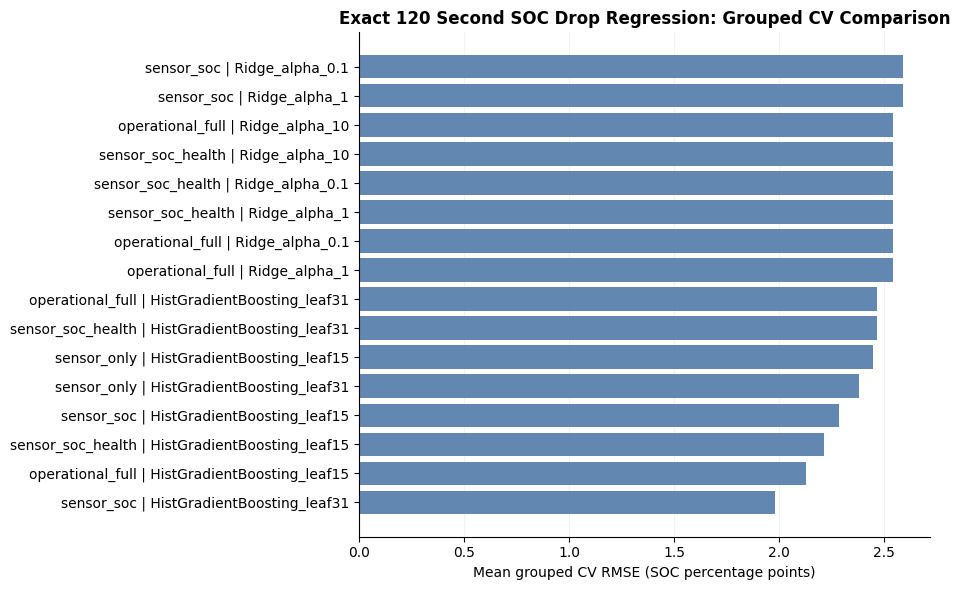

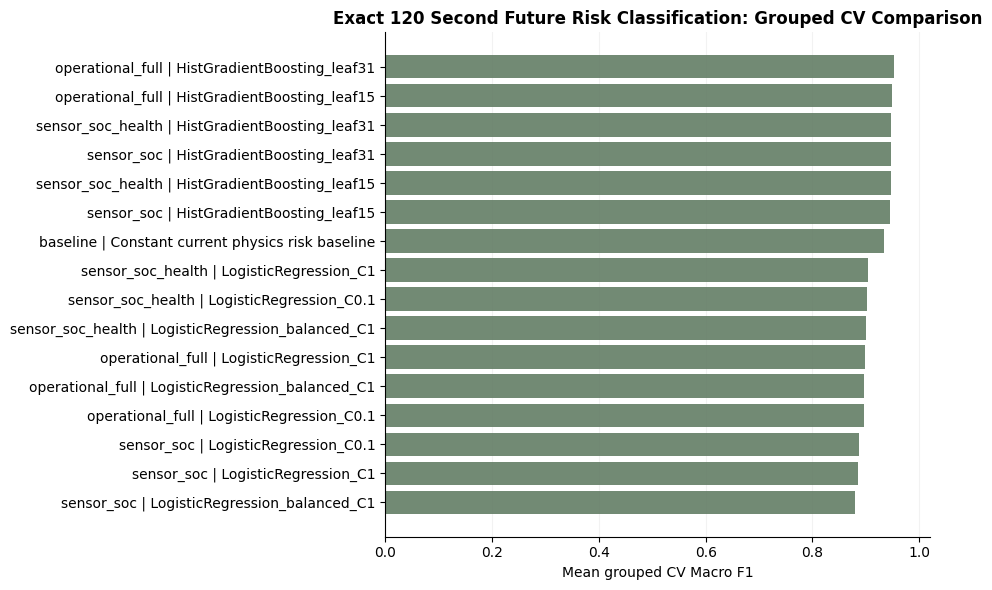

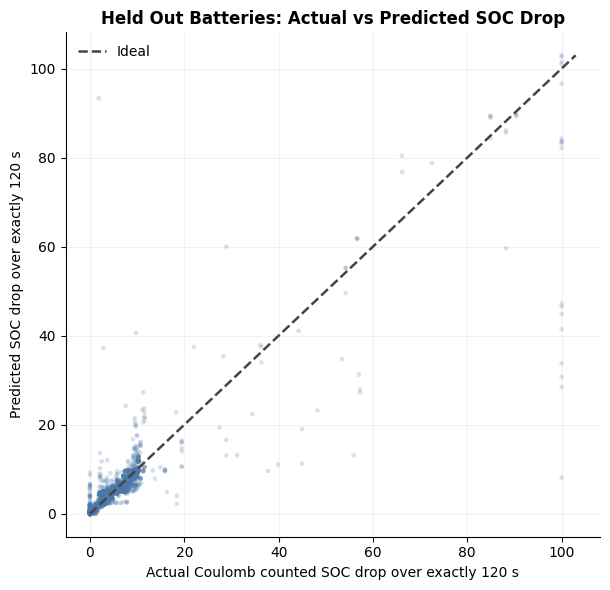

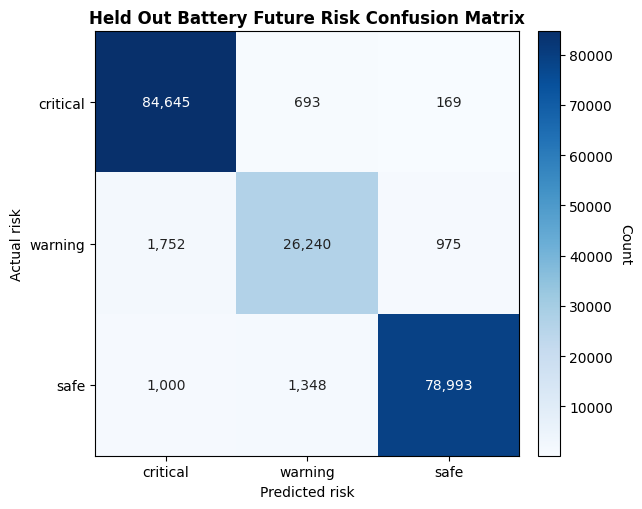

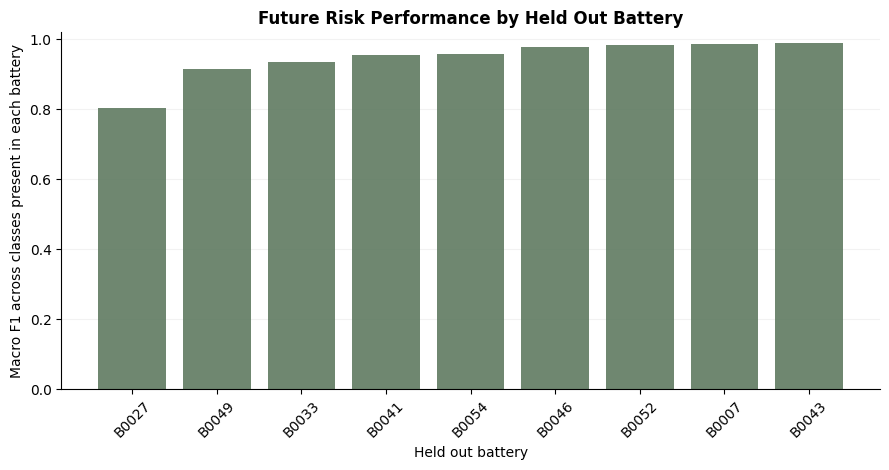

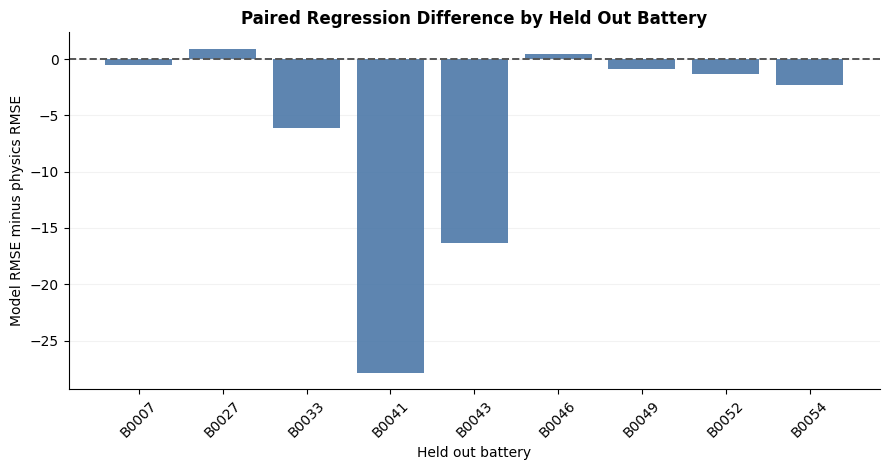

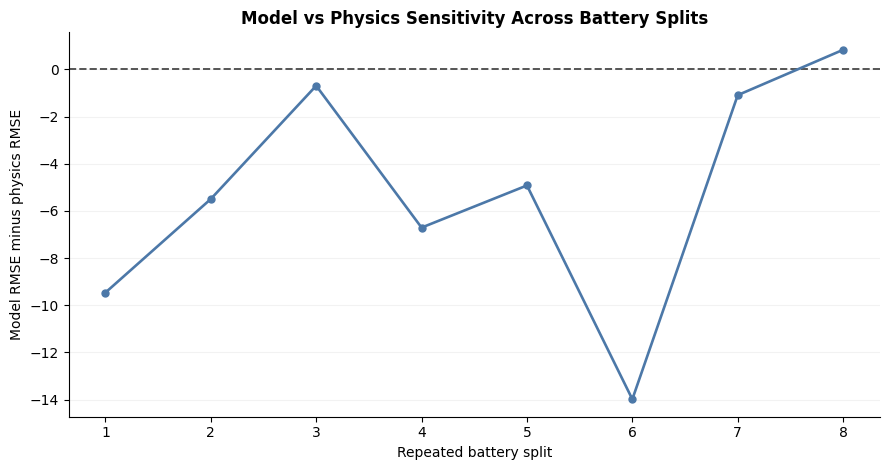

Saved model bundle to: /content/final_nasa_physical_targets_outputs/model_bundle
Saved NASA reference sample for Gymnasium domain audit: /content/final_nasa_physical_targets_outputs/model_bundle/practical_feature_reference_sample.csv


In [22]:
# 14. SAVE MODEL BUNDLES, DOMAIN REFERENCE DATA, METADATA, AND PLOTS

practical_features = feature_sets[
    'sensor_soc_health'
]

feature_range_rows = []

for feature in practical_features:
    values = (
        trainval_df[feature]
        .dropna()
        .astype(float)
    )

    feature_range_rows.append(
        {
            'feature': feature,
            'minimum': values.min(),
            'q01': values.quantile(0.01),
            'q05': values.quantile(0.05),
            'median': values.median(),
            'q95': values.quantile(0.95),
            'q99': values.quantile(0.99),
            'maximum': values.max(),
        }
    )

feature_ranges_df = pd.DataFrame(
    feature_range_rows
)
feature_ranges_df.to_csv(
    MODEL_OUTPUT_DIR
    / 'practical_feature_ranges.csv',
    index=False,
)

# Save a balanced development data reference sample for the Gymnasium
# domain shift audit. This is not used to train the simulator.
reference_columns = (
    ['battery_id']
    + practical_features
)

practical_reference_sample = balanced_group_sample(
    trainval_df[reference_columns],
    max_rows=20_000,
    random_state=RANDOM_STATE + 900,
)

practical_reference_sample.to_csv(
    MODEL_OUTPUT_DIR
    / 'practical_feature_reference_sample.csv',
    index=False,
)

practical_reference_sample[
    practical_features
].corr().to_csv(
    MODEL_OUTPUT_DIR
    / 'practical_feature_reference_correlations.csv'
)

bundle_metadata = {
    'project': (
        'NASA battery exact fixed time '
        'Coulomb counted monitoring'
    ),
    'created_utc': (
        datetime.utcnow().isoformat() + 'Z'
    ),
    'random_state': RANDOM_STATE,
    'forecast_horizon_seconds': (
        FORECAST_HORIZON_SECONDS
    ),
    'future_value_method': (
        'linear interpolation at exactly '
        't + 120 seconds'
    ),
    'maximum_interpolation_bracket_seconds': (
        MAX_INTERPOLATION_BRACKET_SECONDS
    ),
    'rolling_feature_window_seconds': (
        ROLLING_WINDOW_SECONDS
    ),
    'risk_thresholds_percent': {
        'critical_below': (
            CRITICAL_SOC_THRESHOLD
        ),
        'warning_below': (
            SAFE_SOC_THRESHOLD
        ),
        'safe_at_or_above': (
            SAFE_SOC_THRESHOLD
        ),
    },
    'regression_target': REGRESSION_TARGET,
    'classification_target': (
        CLASSIFICATION_TARGET
    ),
    'target_definition': (
        'Change in retrospective Coulomb counted SOC '
        'between t and exactly t + 120 seconds. '
        'Current cycle measured capacity is used only '
        'to construct retrospective labels.'
    ),
    'operational_soc_definition': (
        'Coulomb counted SOC using a rolling capacity '
        'estimate from previously completed cycles.'
    ),
    'current_sign_convention': {
        'current_measured_a': (
            'predominantly negative during discharge'
        ),
        'current_load_a': (
            'predominantly non-negative load magnitude'
        ),
    },
    'trainval_batteries': (
        trainval_batteries.tolist()
    ),
    'test_batteries': test_batteries.tolist(),
    'n_group_folds': N_GROUP_FOLDS,
    'n_split_sensitivity_runs': (
        N_SPLIT_SENSITIVITY_RUNS
    ),
    'best_overall': {
        'soc_drop_model': best_reg_row[
            'model'
        ],
        'soc_drop_feature_set': (
            best_reg_row['feature_set']
        ),
        'soc_drop_features': (
            best_reg_features
        ),
        'future_risk_model': (
            best_cls_row['model']
        ),
        'future_risk_feature_set': (
            best_cls_row['feature_set']
        ),
        'future_risk_features': (
            best_cls_features
        ),
    },
    'practical_bms_style': {
        'soc_drop_model': (
            practical_reg_row['model']
        ),
        'soc_drop_feature_set': (
            practical_reg_row['feature_set']
        ),
        'soc_drop_features': (
            practical_reg_features
        ),
        'future_risk_model': (
            practical_cls_row['model']
        ),
        'future_risk_feature_set': (
            practical_cls_row['feature_set']
        ),
        'future_risk_features': (
            practical_cls_features
        ),
    },
    'probability_note': (
        'Classifier probabilities are logged but '
        'are not formally calibrated.'
    ),
    'rul_note': (
        'RUL is an exploratory secondary analysis '
        'because its label and health features derive '
        'from the same capacity-degradation trajectory.'
    ),
}

with open(
    MODEL_OUTPUT_DIR
    / 'model_bundle_metadata.json',
    'w',
) as file:
    json.dump(
        bundle_metadata,
        file,
        indent=2,
    )

joblib.dump(
    best_reg_model,
    MODEL_OUTPUT_DIR
    / 'best_soc_drop_regressor.joblib',
)
joblib.dump(
    best_reg_features,
    MODEL_OUTPUT_DIR
    / 'best_soc_drop_features.joblib',
)
joblib.dump(
    best_cls_model,
    MODEL_OUTPUT_DIR
    / 'best_future_risk_classifier.joblib',
)
joblib.dump(
    best_cls_features,
    MODEL_OUTPUT_DIR
    / 'best_future_risk_features.joblib',
)

joblib.dump(
    practical_reg_model,
    MODEL_OUTPUT_DIR
    / 'practical_soc_drop_regressor.joblib',
)
joblib.dump(
    practical_reg_features,
    MODEL_OUTPUT_DIR
    / 'practical_soc_drop_features.joblib',
)
joblib.dump(
    practical_cls_model,
    MODEL_OUTPUT_DIR
    / 'practical_future_risk_classifier.joblib',
)
joblib.dump(
    practical_cls_features,
    MODEL_OUTPUT_DIR
    / 'practical_future_risk_features.joblib',
)

figure, axis = plt.subplots(figsize=(9.5, 6.0))
plot_df = (
    regression_cv_summary_df
    .head(16)
    .sort_values(
        'cv_rmse_mean',
        ascending=True,
    )
)
plot_labels = (
    plot_df['feature_set']
    + ' | '
    + plot_df['model']
)
axis.barh(
    plot_labels,
    plot_df['cv_rmse_mean'],
    color='#4C78A8',
    alpha=0.88,
)
axis.set_xlabel(
    'Mean grouped CV RMSE '
    '(SOC percentage points)'
)
axis.set_title(
    'Exact 120 Second SOC Drop Regression: '
    'Grouped CV Comparison',
    fontsize=12,
    fontweight='semibold',
)
axis.grid(axis='x', alpha=0.16, linewidth=0.8)
axis.set_axisbelow(True)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'regression_grouped_cv_comparison.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

figure, axis = plt.subplots(figsize=(9.5, 6.0))
plot_df = (
    classification_cv_summary_df
    .head(16)
    .sort_values(
        'cv_macro_f1_mean',
        ascending=True,
    )
)
plot_labels = (
    plot_df['feature_set']
    + ' | '
    + plot_df['model']
)
axis.barh(
    plot_labels,
    plot_df['cv_macro_f1_mean'],
    color='#5F7A61',
    alpha=0.88,
)
axis.set_xlabel(
    'Mean grouped CV Macro F1'
)
axis.set_xlim(0.0, 1.02)
axis.set_title(
    'Exact 120 Second Future Risk Classification: '
    'Grouped CV Comparison',
    fontsize=12,
    fontweight='semibold',
)
axis.grid(axis='x', alpha=0.16, linewidth=0.8)
axis.set_axisbelow(True)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'classification_grouped_cv_comparison.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

plot_sample = practical_reg_predictions.sample(
    n=min(
        20_000,
        len(practical_reg_predictions),
    ),
    random_state=RANDOM_STATE,
)

figure, axis = plt.subplots(figsize=(6.2, 6.0))
axis.scatter(
    plot_sample[REGRESSION_TARGET],
    plot_sample[
        'predicted_soc_drop_120s'
    ],
    alpha=0.22,
    s=11,
    color='#4C78A8',
    edgecolors='none',
)
limits = [
    min(
        plot_sample[
            REGRESSION_TARGET
        ].min(),
        plot_sample[
            'predicted_soc_drop_120s'
        ].min(),
    ),
    max(
        plot_sample[
            REGRESSION_TARGET
        ].max(),
        plot_sample[
            'predicted_soc_drop_120s'
        ].max(),
    ),
]
axis.plot(
    limits,
    limits,
    linestyle='--',
    linewidth=1.8,
    color='#444444',
    label='Ideal',
)
axis.set_xlabel(
    'Actual Coulomb counted SOC drop '
    'over exactly 120 s'
)
axis.set_ylabel(
    'Predicted SOC drop '
    'over exactly 120 s'
)
axis.set_title(
    'Held Out Batteries: '
    'Actual vs Predicted SOC Drop',
    fontsize=12,
    fontweight='semibold',
)
axis.grid(alpha=0.16, linewidth=0.8)
axis.set_axisbelow(True)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.legend(frameon=False)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'actual_vs_predicted_soc_drop_test.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

confusion = confusion_matrix(
    practical_cls_predictions[CLASSIFICATION_TARGET],
    practical_cls_predictions['predicted_future_risk_120s'],
    labels=risk_order,
)

figure, axis = plt.subplots(figsize=(6.2, 5.2))
image = axis.imshow(
    confusion,
    interpolation='nearest',
    cmap='Blues',
)
axis.set_xticks(
    range(len(risk_order)),
    labels=risk_order,
)
axis.set_yticks(
    range(len(risk_order)),
    labels=risk_order,
)
axis.set_xlabel('Predicted risk')
axis.set_ylabel('Actual risk')
axis.set_title(
    'Held Out Battery '
    'Future Risk Confusion Matrix',
    fontsize=12,
    fontweight='semibold',
)

text_threshold = confusion.max() / 2.0
for row in range(confusion.shape[0]):
    for column in range(
        confusion.shape[1]
    ):
        axis.text(
            column,
            row,
            f'{confusion[row, column]:,}',
            ha='center',
            va='center',
            color=(
                'white'
                if confusion[row, column] > text_threshold
                else '#222222'
            ),
            fontsize=10,
        )

colorbar = figure.colorbar(
    image,
    ax=axis,
    fraction=0.046,
    pad=0.04,
)
colorbar.ax.set_ylabel(
    'Count',
    rotation=270,
    labelpad=14,
)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'practical_classifier_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

figure, axis = plt.subplots(figsize=(9.0, 4.8))
ordered = best_cls_battery.sort_values(
    'model_macro_f1'
)
axis.bar(
    ordered['battery_id'],
    ordered['model_macro_f1'],
    color='#5F7A61',
    alpha=0.9,
)
axis.set_ylim(0.0, 1.02)
axis.set_ylabel(
    'Macro F1 across classes '
    'present in each battery'
)
axis.set_xlabel('Held out battery')
axis.set_title(
    'Future Risk Performance '
    'by Held Out Battery',
    fontsize=12,
    fontweight='semibold',
)
axis.tick_params(axis='x', rotation=45)
axis.grid(axis='y', alpha=0.16, linewidth=0.8)
axis.set_axisbelow(True)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'classification_macro_f1_by_test_battery.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

figure, axis = plt.subplots(figsize=(9.0, 4.8))
axis.axhline(
    0.0,
    linestyle='--',
    linewidth=1.4,
    color='#555555',
)
axis.bar(
    best_reg_battery['battery_id'],
    best_reg_battery[
        'model_minus_physics_rmse'
    ],
    color='#4C78A8',
    alpha=0.9,
)
axis.set_ylabel(
    'Model RMSE minus physics RMSE'
)
axis.set_xlabel('Held out battery')
axis.set_title(
    'Paired Regression Difference '
    'by Held Out Battery',
    fontsize=12,
    fontweight='semibold',
)
axis.tick_params(axis='x', rotation=45)
axis.grid(axis='y', alpha=0.16, linewidth=0.8)
axis.set_axisbelow(True)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'paired_regression_difference_by_battery.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

figure, axis = plt.subplots(figsize=(9.0, 4.8))
axis.axhline(
    0.0,
    linestyle='--',
    linewidth=1.4,
    color='#555555',
)
axis.plot(
    split_sensitivity_df[
        'split_number'
    ],
    split_sensitivity_df[
        'regression_model_minus_physics_rmse'
    ],
    marker='o',
    markersize=5,
    linewidth=1.9,
    color='#4C78A8',
    label='RMSE difference',
)
axis.set_xlabel('Repeated battery split')
axis.set_ylabel(
    'Model RMSE minus physics RMSE'
)
axis.set_title(
    'Model vs Physics Sensitivity '
    'Across Battery Splits',
    fontsize=12,
    fontweight='semibold',
)
axis.grid(axis='y', alpha=0.16, linewidth=0.8)
axis.set_axisbelow(True)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'repeated_split_regression_sensitivity.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

print(
    'Saved model bundle to:',
    MODEL_OUTPUT_DIR,
)
print(
    'Saved NASA reference sample for '
    'Gymnasium domain audit:',
    MODEL_OUTPUT_DIR
    / 'practical_feature_reference_sample.csv',
)

In [23]:
# 15. FINAL SUMMARY AND COPY OUTPUTS TO DRIVE

final_summary = {
    'unique_batteries': int(
        model_df['battery_id'].nunique()
    ),
    'unique_discharge_cycles_with_targets': int(
        model_df['cycle_uid'].nunique()
    ),
    'physical_target_rows': int(
        len(model_df)
    ),
    'development_batteries': int(
        len(trainval_batteries)
    ),
    'held_out_test_batteries': int(
        len(test_batteries)
    ),
    'forecast_horizon_seconds_exact': (
        FORECAST_HORIZON_SECONDS
    ),
    'maximum_interpolation_bracket_seconds': (
        MAX_INTERPOLATION_BRACKET_SECONDS
    ),
    'rolling_feature_window_seconds': (
        ROLLING_WINDOW_SECONDS
    ),
    'best_regression_model': (
        best_reg_row['model']
    ),
    'best_regression_feature_set': (
        best_reg_row['feature_set']
    ),
    'best_regression_test_rmse': (
        best_reg_pooled['rmse']
    ),
    'best_regression_test_r2': (
        best_reg_pooled['r2']
    ),
    'best_classifier_model': (
        best_cls_row['model']
    ),
    'best_classifier_feature_set': (
        best_cls_row['feature_set']
    ),
    'best_classifier_test_macro_f1': (
        best_cls_pooled['macro_f1']
    ),
    'best_classifier_test_critical_recall': (
        best_cls_pooled['critical_recall']
    ),
    'practical_regression_model': (
        practical_reg_row['model']
    ),
    'practical_classifier_model': (
        practical_cls_row['model']
    ),
    'repeated_split_runs': (
        N_SPLIT_SENSITIVITY_RUNS
    ),
    'observed_eol_batteries': int(
        eol_summary['eol_observed'].sum()
    ),
    'censored_batteries': int(
        (
            ~eol_summary['eol_observed']
        ).sum()
    ),
}

with open(
    BASE_OUTPUT_DIR
    / 'final_notebook_summary.json',
    'w',
) as file:
    json.dump(
        final_summary,
        file,
        indent=2,
    )

try:
    DRIVE_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    for source_path in BASE_OUTPUT_DIR.rglob('*'):
        if source_path.is_file():
            relative_path = source_path.relative_to(
                BASE_OUTPUT_DIR
            )
            destination = (
                DRIVE_OUTPUT_DIR
                / relative_path
            )
            destination.parent.mkdir(
                parents=True,
                exist_ok=True,
            )
            shutil.copy2(
                source_path,
                destination,
            )

    print(
        'Copied final outputs to Drive:',
        DRIVE_OUTPUT_DIR,
    )
except Exception as exc:
    print(
        'Could not copy outputs '
        'to Google Drive:',
        exc,
    )

print('\nFINAL SUMMARY')
display(
    pd.Series(
        final_summary,
        name='value',
    )
)

Copied final outputs to Drive: /content/drive/MyDrive/dissertation/02_nasa_physical_targets_final_outputs

FINAL SUMMARY


,value
unique_batteries,34
unique_discharge_cycles_with_targets,2692
physical_target_rows,722976
development_batteries,25
held_out_test_batteries,9
forecast_horizon_seconds_exact,120.0
maximum_interpolation_bracket_seconds,60.0
rolling_feature_window_seconds,60.0
best_regression_model,HistGradientBoosting_leaf31
best_regression_feature_set,sensor_soc
